# <font color=#0099CC>**PREPROCESADO PARA ML FINANCIERO**</font>

### **Fecha: 19/03/2026 | Autores: Daniel Gallego Sánchez & Javier Fernández Guerra**

## <font color=#0099CC>**0. INTRODUCCIÓN**</font>

### <font color=#336699>**0.1. Contexto: ¿por qué el ML estándar falla en finanzas?**</font>

El Machine Learning estándar asume que los datos son **i.i.d.** (independientes e idénticamente distribuidos). Los datos financieros violan eso sistemáticamente:

| Problema | Por qué ocurre |
|----------|----------------|
| **No son independientes** | El precio de mañana depende del de hoy |
| **Distribución cambiante** | La volatilidad de 2008 ≠ la de 2021 |
| **El pasado se filtra al futuro** | Sin cuidado, el modelo "ve" el futuro al entrenar |
| **Etiquetas irrealistas** | Etiquetar sin stop-losses no refleja el trading real |

> **Idea de López de Prado:** la mayoría de estrategias publicadas son falsos positivos — funcionan en datos históricos por sobreajuste, no porque descubrieran algo real.

### <font color=#336699>**0.2. Las 5 técnicas de este notebook**</font>

1. **Barras alternativas** → muestrear por actividad económica, no por tiempo
2. **Diferenciación fraccional** → estacionariedad sin perder memoria
3. **Limpieza de covarianza** → separar señal real de ruido estadístico
4. **Triple barrera** → etiquetar con gestión de riesgo implícita
5. **Purged K-Fold** → validación sin fuga de información temporal

## <font color=#0099CC>**1. CONFIGURACIÓN INICIAL**</font>

Se importan las librerías necesarias (NumPy, Pandas, Matplotlib, SciPy, etc.) y se descargan datos OHLCV de criptomonedas desde la API de Binance. Estos datos constituyen la materia prima para todas las técnicas del notebook.


### <font color=#336699>**1.1. Imports y Librerías**</font>

In [1]:
# LIBRERÍAS
import numpy as np                       # operaciones matemáticas con arrays
import pandas as pd                      # series temporales y DataFrames
import matplotlib.pyplot as plt          # gráficos
import matplotlib.patches as mpatches    # parches para leyendas
import matplotlib.gridspec as gridspec   # layouts complejos de subplots
from matplotlib.colors import LogNorm    # escala logarítmica para colormaps
import requests                          # llamadas HTTP a la API de Binance
from math import ceil                    # redondeo hacia arriba
from collections import Counter          # contar ocurrencias
from numpy.linalg import eigh            # eigendescomposición (matrices simétricas)
import warnings
warnings.filterwarnings('ignore')        # ocultamos advertencias menores

# GRÁFICOS
# Estilo visual global
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams.update({
    'figure.facecolor': 'white',
    'axes.facecolor':   'white',
    'font.size':        11,
    'axes.titlesize':   12,
    'axes.labelsize':   11,
    'axes.titleweight': 'bold',
})

# Paleta de colores consistente en todo el notebook
COLORS = {
    'time':   '#E74C3C',   # rojo   → time bars (el "problema")
    'tick':   '#F39C12',   # naranja→ tick bars
    'volume': '#3498DB',   # azul   → volume bars
    'dollar': '#27AE60',   # verde  → dollar bars (la solución )
    'signal': '#E74C3C',   # rojo   → eigenvalores de señal
    'noise':  '#95A5A6',   # gris   → eigenvalores de ruido
    'train':  '#2980B9',   # azul   → training set
    'test':   '#E74C3C',   # rojo   → test set
    'purge':  '#F0C0D8',   # rosa   → zona purgada/embargo
}

print("> Librerías importadas")

> Librerías importadas


### <font color=#336699>**1.2. Descarga de Datos**</font>

Se descargan datos OHLCV de 5 activos (BTC, ETH, BNB, SOL, XRP) en velas de 5 minutos desde la API de Binance, con caché local para evitar re-descargas.

In [8]:
# DESCARGA DE DATOS MULTI-ACTIVO (BINANCE, 5m)
# Objetivo:
#   1) Mantener BTC para T1/T2/T4/T5 (pipeline didáctico existente)
#   2) Construir dataset sincronizado multi-activo para T3

from pathlib import Path
import time

SYMBOLS    = ['BTCUSDT', 'ETHUSDT', 'BNBUSDT', 'SOLUSDT', 'XRPUSDT']
INTERVAL   = '5m'
START_DATE = '2023-03-15'
END_DATE   = '2026-03-15'
BASE_URL   = 'https://api.binance.com/api/v3/klines'

# Cache reproducible por activo + intervalo + rango de fechas.
CACHE_DIR = Path('cache_binance_ohlcv')
CACHE_DIR.mkdir(parents=True, exist_ok=True)


def _fecha_a_ms(fecha_str, cierre=False):
    """
    Convierte YYYY-MM-DD a timestamp en milisegundos (UTC).
    Si cierre=True, usa el ?ltimo milisegundo del d?a.
    """
    ts = pd.Timestamp(fecha_str, tz='UTC')
    if cierre:
        ts = ts + pd.Timedelta(days=1) - pd.Timedelta(milliseconds=1)
    return int(ts.timestamp() * 1000)


def ruta_cache(symbol, interval, start_date, end_date):
    """Nombre de cache inequ?voco para garantizar trazabilidad."""
    start_key = pd.Timestamp(start_date).strftime('%Y%m%d')
    end_key   = pd.Timestamp(end_date).strftime('%Y%m%d')
    return CACHE_DIR / f'{symbol}_{interval}_{start_key}_{end_key}.csv'


def descargar_binance_ohlcv(symbol, interval, start_date, end_date, limit=1000, pausa=0.05, max_retries=5):
    """
    Descarga OHLCV desde la API p?blica de Binance con paginaci?n.

    Binance limita cada petici?n a 1000 velas, por lo que iteramos por bloques
    hasta cubrir todo el rango solicitado.
    """
    start_ts = _fecha_a_ms(start_date, cierre=False)
    end_ts   = _fecha_a_ms(end_date, cierre=True)

    filas = []
    actual = start_ts
    n_peticiones = 0

    while actual <= end_ts:
        params = {
            'symbol': symbol,
            'interval': interval,
            'startTime': actual,
            'endTime': end_ts,
            'limit': limit,
        }

        for intento in range(max_retries):
            try:
                resp = requests.get(BASE_URL, params=params, timeout=20)
                resp.raise_for_status()
                bloque = resp.json()
                break
            except requests.RequestException:
                if intento == max_retries - 1:
                    raise
                espera = min(8, 2 ** intento)
                time.sleep(espera)

        if not bloque:
            break

        filas.extend(bloque)
        actual = bloque[-1][6] + 1
        n_peticiones += 1

        if n_peticiones % 50 == 0:
            print(f'   {symbol}: {n_peticiones} peticiones completadas...')

        time.sleep(pausa)

    if not filas:
        raise ValueError(f'No se descargaron datos para {symbol}.')

    cols = [
        'open_time', 'open', 'high', 'low', 'close', 'volume',
        'close_time', 'quote_vol', 'n_trades', 'taker_base', 'taker_quote', 'ignore'
    ]
    df = pd.DataFrame(filas, columns=cols)

    # Pasamos a datetime y mantenemos ?ndice naive en UTC para joins consistentes.
    df['datetime'] = pd.to_datetime(df['open_time'], unit='ms', utc=True).dt.tz_convert(None)
    df = df.set_index('datetime')[['open', 'high', 'low', 'close', 'volume']].astype(float)
    df = df.sort_index()
    df = df[~df.index.duplicated(keep='last')]

    # Valor monetario por vela: ?til para dollar bars en T1.
    df['dollar_vol'] = df['close'] * df['volume']
    return df


def cargar_o_descargar_symbol(symbol, interval, start_date, end_date):
    """
    Carga desde cache si existe exactamente para el mismo rango.
    Si no existe, descarga y guarda en CSV individual.
    """
    csv_path = ruta_cache(symbol, interval, start_date, end_date)

    if csv_path.exists():
        df = pd.read_csv(csv_path, parse_dates=['datetime'], index_col='datetime')
        df = df.sort_index()
        if 'dollar_vol' not in df.columns:
            df['dollar_vol'] = df['close'] * df['volume']
        origen = 'cache'
    else:
        print(f' Descargando {symbol} {interval} ({start_date} -> {end_date})...')
        df = descargar_binance_ohlcv(symbol, interval, start_date, end_date)
        df.to_csv(csv_path)
        origen = 'binance'

    return df, csv_path, origen


# Descarga/carga multi-activo
datos_por_activo = {}

print('Carga de datos OHLCV por activo:')
for symbol in SYMBOLS:
    df_symbol, csv_path, origen = cargar_o_descargar_symbol(
        symbol=symbol,
        interval=INTERVAL,
        start_date=START_DATE,
        end_date=END_DATE,
    )
    datos_por_activo[symbol] = df_symbol

    print(
        f'  > {symbol}: {len(df_symbol):,} velas | '
        f'{df_symbol.index.min()} -> {df_symbol.index.max()} | origen={origen} | archivo={csv_path.name}'
    )

# Tabla sincronizada multi-activo para T3 (inner join por timestamp)
close_frames = [
    df[['close']].rename(columns={'close': symbol})
    for symbol, df in datos_por_activo.items()
]
volume_frames = [
    df[['volume']].rename(columns={'volume': symbol})
    for symbol, df in datos_por_activo.items()
]

datos_multi_close = pd.concat(close_frames, axis=1, join='inner').dropna().sort_index()
datos_multi_volume = pd.concat(volume_frames, axis=1, join='inner').dropna().sort_index()

if datos_multi_close.empty:
    raise ValueError('La unidad temporal entre activos queda vacía. Revisa rango de fechas o símbolos.')

# Mantener pipeline BTC para T1/T2/T4/T5 sin cambios estructurales.
datos_raw = datos_por_activo['BTCUSDT'].copy()

print('\nResumen final de datos:')
print(f'  > Activos en T3: {SYMBOLS}')
print(f'  > Frecuencia: {INTERVAL}')
print(f'  > Filas sincronizadas (5 activos): {len(datos_multi_close):,}')
print(f'  > Rango sincronizado: {datos_multi_close.index.min()} -> {datos_multi_close.index.max()}')
print(f'  > BTC para T1/T2/T4/T5: {len(datos_raw):,} velas')

print('\nDataframe:')
display(datos_multi_close.head(3))

Carga de datos OHLCV por activo:
  > BTCUSDT: 315,920 velas | 2023-03-15 00:00:00 -> 2026-03-15 23:55:00 | origen=cache | archivo=BTCUSDT_5m_20230315_20260315.csv
  > ETHUSDT: 315,920 velas | 2023-03-15 00:00:00 -> 2026-03-15 23:55:00 | origen=cache | archivo=ETHUSDT_5m_20230315_20260315.csv
  > BNBUSDT: 315,920 velas | 2023-03-15 00:00:00 -> 2026-03-15 23:55:00 | origen=cache | archivo=BNBUSDT_5m_20230315_20260315.csv
  > SOLUSDT: 315,920 velas | 2023-03-15 00:00:00 -> 2026-03-15 23:55:00 | origen=cache | archivo=SOLUSDT_5m_20230315_20260315.csv
  > XRPUSDT: 315,920 velas | 2023-03-15 00:00:00 -> 2026-03-15 23:55:00 | origen=cache | archivo=XRPUSDT_5m_20230315_20260315.csv

Resumen final de datos:
  > Activos en T3: ['BTCUSDT', 'ETHUSDT', 'BNBUSDT', 'SOLUSDT', 'XRPUSDT']
  > Frecuencia: 5m
  > Filas sincronizadas (5 activos): 315,920
  > Rango sincronizado: 2023-03-15 00:00:00 -> 2026-03-15 23:55:00
  > BTC para T1/T2/T4/T5: 315,920 velas

Dataframe:


,BTCUSDT,ETHUSDT,BNBUSDT,SOLUSDT,XRPUSDT
datetime,,,,,
2023-03-15 00:00:00,24696.14,1701.98,308.7,20.89,0.3727
2023-03-15 00:05:00,24655.13,1698.48,307.7,20.81,0.3717
2023-03-15 00:10:00,24569.27,1696.41,307.3,20.78,0.3714


## <font color=#0099CC>**2. BARRAS DE TICK, VOLUMEN Y DÓLAR**</font>

### <font color=#336699>**2.1. Motivación para la construcción de barras alternativas**</font>

En el enfoque clásico, los datos financieros se organizan en **barras temporales** (1 min, 5 min, etc.), lo que implica asumir que cada intervalo contiene una cantidad similar de información. En la práctica, esta hipótesis no se sostiene: la actividad de mercado es altamente irregular, concentrándose en momentos como aperturas, cierres o eventos macro, y reduciéndose drásticamente en otros periodos.

Esto introduce un problema estructural: intervalos con muy distinta intensidad de negociación reciben el mismo peso estadístico. Como consecuencia, los retornos presentan **heterocedasticidad intradiaria** (la varianza cambia de forma sistemática a lo largo del día), lo que degrada el rendimiento de modelos de ML al violar la suposición de estabilidad en la distribución de los datos.

La propuesta de López de Prado (2018) consiste en redefinir las barras para que se cierren en función de la **actividad económica** en lugar del tiempo. Así, cada observación incorpora una cantidad de información más homogénea, produciendo series de retornos mejor condicionadas (más cercanas a homocedásticas) y, por tanto, más adecuadas para modelado.

Se distinguen tres tipos principales:

| Tipo            | Criterio de cierre                                    | Ventaja principal                                 |
| --------------- | ----------------------------------------------------- | ------------------------------------------------- |
| **Tick bars**   | Cada *T* transacciones                                | Capturan directamente la intensidad de actividad  |
| **Volume bars** | Cada *V* unidades negociadas                          | Reducen el impacto de la fragmentación de órdenes |
| **Dollar bars** | Cada *D* valor monetario negociado (precio × volumen) | Invariantes ante cambios de escala en precios     |


> **Nota:** las dollar bars son el input base para las técnicas T2, T3, T4 y T5 del notebook.


In [24]:
# CONSTRUCCIÓN DE BARRAS ALTERNATIVAS

# Función auxiliar: resumir un grupo de filas en una barra OHLCV
def agrupar_barra(filas):
    """
    Recibe una lista de filas (pd.Series) y devuelve un dict OHLCV.
    OHLCV = Open (apertura), High (máximo), Low (mínimo), Close (cierre), Volume.
    """
    df = pd.DataFrame(filas)
    return {
        'open':       df['open'].iloc[0],      # precio de la primera fila del grupo
        'high':       df['high'].max(),         # precio máximo del grupo
        'low':        df['low'].min(),          # precio mínimo del grupo
        'close':      df['close'].iloc[-1],    # precio de la última fila del grupo
        'volume':     df['volume'].sum(),      # volumen total acumulado
        'dollar_vol': df['dollar_vol'].sum(),  # valor monetario total (precio×vol)
        'n_ticks':    len(df),                 # número de velas 1m que contiene
    }

# Tick Bars: una barra cada T transacciones (filas)
def hacer_tick_bars(df, T=500):
    """
    Tick bars: cierra una barra cada T filas (transacciones).
    Como usamos velas 1-min, cada fila se trata como una transacción.
    """
    barras, chunk = [], []
    for ts, fila in df.iterrows():
        chunk.append(fila)                   # añadimos la fila al buffer
        if len(chunk) >= T:                  # cuando llegamos a T, cerramos la barra
            barra = agrupar_barra(chunk)
            barra['timestamp'] = ts          # timestamp de cierre de la barra
            barras.append(barra)
            chunk = []                       # reiniciamos el buffer
    return pd.DataFrame(barras).set_index('timestamp')

# Volume Bars: una barra cada V unidades de volumen
def hacer_volume_bars(df, V=100_000):
    """
    Volume bars: cierra una barra cuando el volumen acumulado supera V.
    V se mide en la unidad del activo (BTC en este caso).
    """
    barras, chunk, vol_acum = [], [], 0.0
    for ts, fila in df.iterrows():
        chunk.append(fila)
        vol_acum += fila['volume']           # acumulamos el volumen de esta vela
        if vol_acum >= V:                    # cuando superamos el umbral, cerramos
            barra = agrupar_barra(chunk)
            barra['timestamp'] = ts
            barras.append(barra)
            chunk, vol_acum = [], 0.0        # reiniciamos ambos contadores
    return pd.DataFrame(barras).set_index('timestamp')

# Dollar Bars: una barra cada D dólares de valor monetario
def hacer_dollar_bars(df, D=1_000_000_000):
    """
    Dollar bars: cierra una barra cuando el valor monetario acumulado
    (precio × volumen) supera D dólares.
    
    Este es el tipo preferido por López de Prado porque:
    • Es inmune a splits de acciones (el valor monetario no cambia)
    • Es inmune a variaciones del precio del activo
    • Produce distribuciones de retornos más cercanas a la normal
    """
    barras, chunk, dol_acum = [], [], 0.0
    for ts, fila in df.iterrows():
        chunk.append(fila)
        dol_acum += fila['dollar_vol']       # acumulamos precio×volumen
        if dol_acum >= D:                    # cuando superamos D$, cerramos
            barra = agrupar_barra(chunk)
            barra['timestamp'] = ts
            barras.append(barra)
            chunk, dol_acum = [], 0.0
    return pd.DataFrame(barras).set_index('timestamp')

# Calculamos umbrales para producir ~500 barras de cada tipo
objetivo = 500                                                      # barras objetivo
T_tick   = max(50, len(datos_raw) // objetivo)                     # filas por tick bar
V_vol    = datos_raw['volume'].sum() / objetivo                    # vol por volume bar
D_dol    = datos_raw['dollar_vol'].sum() / objetivo               # $ por dollar bar

print(f"Parámetros para ~{objetivo} barras:")
print(f"  > Tick bars:   {T_tick} filas/barra")
print(f"  > Volume bars: {V_vol:,.0f} BTC/barra")
print(f"  > Dollar bars: {D_dol:,.0f} USD/barra")

# Construimos los tres tipos
tick_bars   = hacer_tick_bars(datos_raw,   T=T_tick)
volume_bars = hacer_volume_bars(datos_raw, V=V_vol)
dollar_bars = hacer_dollar_bars(datos_raw, D=D_dol)   # ← se usa en T2, T3, T4, T5

print(f"\nResultado:")
print(f"  > Time bars:   {len(datos_raw):,}")
print(f"  > Tick bars:       {len(tick_bars):,}")
print(f"  > Volume bars:     {len(volume_bars):,}")
print(f"  > Dollar bars:     {len(dollar_bars):,}")


Parámetros para ~500 barras:
  > Tick bars:   631 filas/barra
  > Volume bars: 74,166 BTC/barra
  > Dollar bars: 4,365,739,462 USD/barra

Resultado:
  > Time bars:   315,920
  > Tick bars:       500
  > Volume bars:     498
  > Dollar bars:     498


> <u>Comentario</u>: A partir de este punto, el pipeline se construye sobre dollar bars, al ser la alternativa más robusta de las tres.
>
> La razón es estructural: ante eventos como un split 2:1, el volumen negociado se duplica, pero el valor monetario (precio × volumen) permanece invariante. Al definir las barras en términos de dólares intercambiados, se elimina este tipo de distorsión, obteniendo una serie temporal más estable y comparable en el tiempo.

### <font color=#336699>**2.3. Visualización Comparativa**</font>

Se comparan las distribuciones de retornos, la frecuencia de muestreo y las propiedades estadísticas de los cuatro tipos de barras (time, tick, volume y dollar) para evidenciar las ventajas del muestreo por actividad económica.

Estadisticos de retornos:


,N barras,Desv.tip.(%),Kurtosis,% ret~0
Tipo,,,,
Time (5m) - referencia temporal,315919,0.1494,99.67,0.4
Tick Bars,499,3.4643,2.28,0.0
Volume Bars,497,3.7416,1.18,0.0
Dollar Bars - solución,497,3.6226,0.46,0.0



Comparativa gráfica de los retornos:


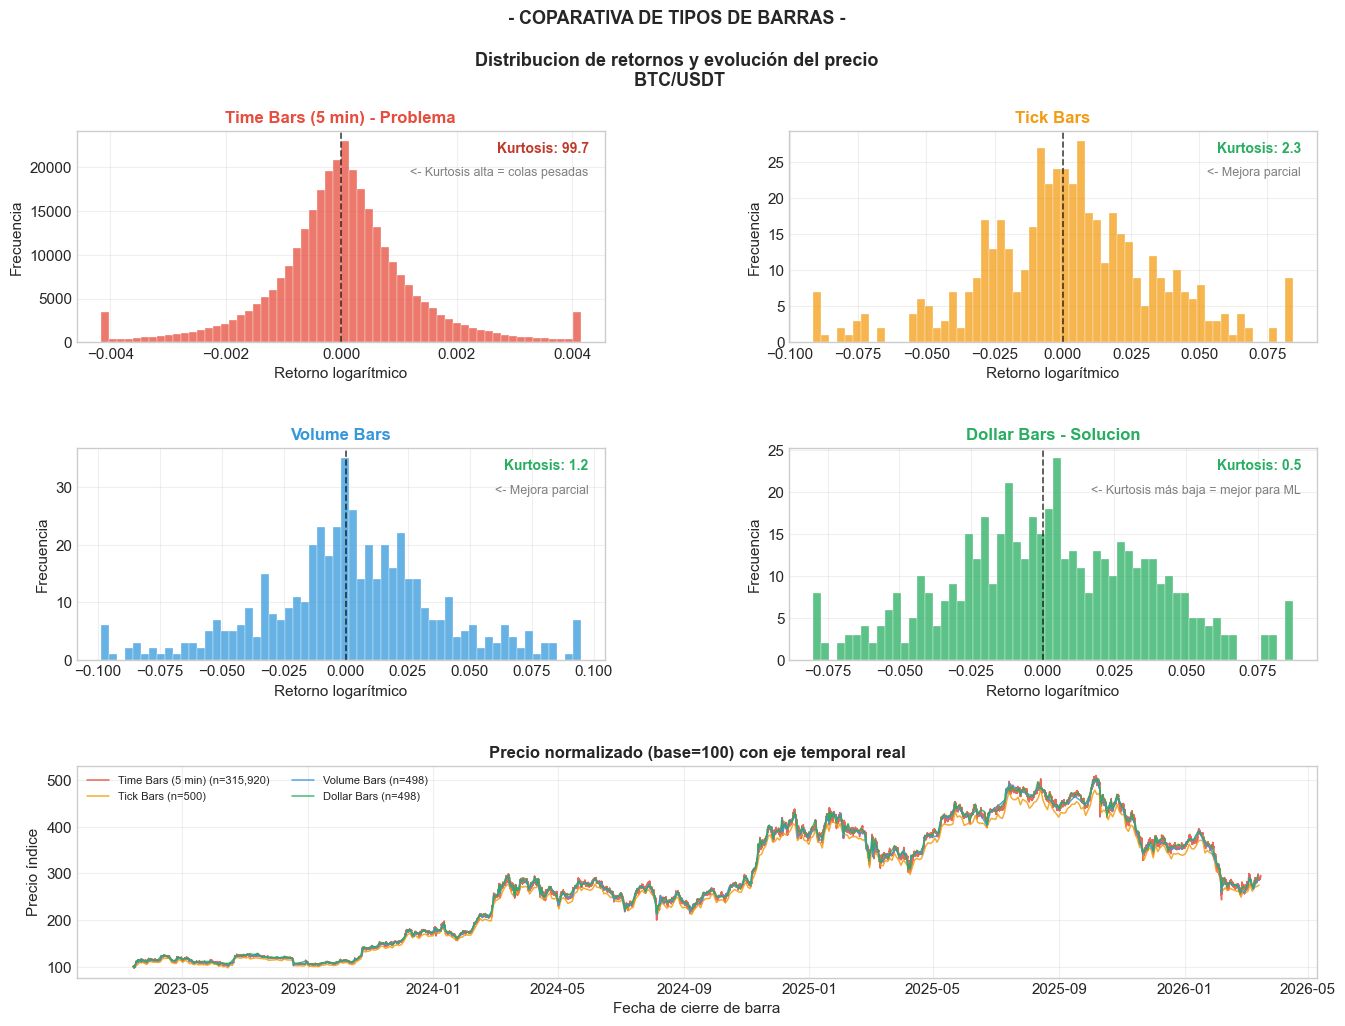

In [15]:
# VISUALIZACIÓN COMPARATIVA
# Objetivo: mostrar que Dollar Bars tienen mejor distribución estadística
# y evitar sesgo visual en el panel temporal usando eje de timestamps reales.

# Calculamos retornos logarítmicos para cada tipo
# log(p_t / p_{t-1}) es el retorno estándar en finanzas cuantitativas
ret_time   = np.log(datos_raw['close']).diff().dropna()
ret_tick   = np.log(tick_bars['close']).diff().dropna()
ret_volume = np.log(volume_bars['close']).diff().dropna()
ret_dollar = np.log(dollar_bars['close']).diff().dropna()

# Tabla de estadísticos resumen
def stats_serie(s, nombre):
    return {
        'Tipo': nombre,
        'N barras': len(s),
        'Desv.tip.(%)': f"{s.std()*100:.4f}",
        'Kurtosis': f"{s.kurtosis():.2f}",   # 0 = normal, >0 = colas pesadas
        '% ret~0': f"{(s.abs()<1e-8).mean()*100:.1f}",
    }

stats_df = pd.DataFrame([
    stats_serie(ret_time,   'Time (5m) - referencia temporal'),
    stats_serie(ret_tick,   'Tick Bars'),
    stats_serie(ret_volume, 'Volume Bars'),
    stats_serie(ret_dollar, 'Dollar Bars - solución'),
])
print("Estadisticos de retornos:")
display(stats_df.set_index('Tipo'))

# Figura
fig = plt.figure(figsize=(16, 11))
gs  = gridspec.GridSpec(3, 2, figure=fig, hspace=0.5, wspace=0.35)
fig.suptitle(
    '- COPARATIVA DE TIPOS DE BARRAS -\n'
    '\nDistribucion de retornos y evolución del precio\n BTC/USDT',
    fontsize=13,
    fontweight='bold',
    y=0.99,
)

series_data = [
    (ret_time,   'Time Bars (5 min) - Problema', COLORS['time'],   '<- Kurtosis alta = colas pesadas'),
    (ret_tick,   'Tick Bars',                     COLORS['tick'],   '<- Mejora parcial'),
    (ret_volume, 'Volume Bars',                   COLORS['volume'], '<- Mejora parcial'),
    (ret_dollar, 'Dollar Bars - Solucion',        COLORS['dollar'], '<- Kurtosis más baja = mejor para ML'),
]

for (row, col), (serie, nombre, color, nota) in zip([(0,0),(0,1),(1,0),(1,1)], series_data):
    ax = fig.add_subplot(gs[row, col])
    q1, q99 = serie.quantile(0.01), serie.quantile(0.99)
    ax.hist(serie.clip(q1, q99), bins=60, color=color, alpha=0.75, edgecolor='white', lw=0.3)
    ax.axvline(0, color='black', lw=1.2, ls='--', alpha=0.7)

    kurt = serie.kurtosis()
    k_color = '#C0392B' if kurt > 5 else '#27AE60'
    ax.text(0.97, 0.95, f"Kurtosis: {kurt:.1f}", transform=ax.transAxes,
            ha='right', va='top', fontsize=10, color=k_color, fontweight='bold')
    ax.text(0.97, 0.83, nota, transform=ax.transAxes,
            ha='right', va='top', fontsize=9, color='gray')

    ax.set_title(nombre, color=color, fontweight='bold')
    ax.set_xlabel('Retorno logarítmico')
    ax.set_ylabel('Frecuencia')
    ax.grid(True, alpha=0.3)

# Panel inferior: precio normalizado con eje temporal real (timestamp de cierre)
# No se usa número de barra para evitar sesgo visual entre series con distinta densidad de muestreo.
ax_p = fig.add_subplot(gs[2, :])
series_precio = [
    (datos_raw['close'],   'Time Bars (5 min)', COLORS['time']),
    (tick_bars['close'],   'Tick Bars',         COLORS['tick']),
    (volume_bars['close'], 'Volume Bars',       COLORS['volume']),
    (dollar_bars['close'], 'Dollar Bars',       COLORS['dollar']),
]

for precio, nombre, color in series_precio:
    precio_norm = (precio / precio.iloc[0]) * 100
    ax_p.plot(
        precio_norm.index,
        precio_norm.values,
        color=color,
        lw=1.1,
        alpha=0.85,
        label=f"{nombre} (n={len(precio_norm):,})",
    )

# Configuración del gráfico
ax_p.set_title('Precio normalizado (base=100) con eje temporal real')
ax_p.set_xlabel('Fecha de cierre de barra')
ax_p.set_ylabel('Precio índice')
ax_p.legend(fontsize=8, ncol=2)
ax_p.grid(True, alpha=0.3)

# Mostramos resultados
plt.savefig('t1_barras.png', dpi=130, bbox_inches='tight')
print('\nComparativa gráfica de los retornos:')
plt.show()

> <u>Comentario</u>: los resultados confirman de forma clara la hipótesis de partida. 
>
>Las time bars de 5 minutos presentan una curtosis excesiva de 99.7, lo que refleja una distribución extremadamente leptocúrtica con colas pesadas, consecuencia directa de la heterocedasticidad intradiaria: la inmensa mayoría de velas contienen muy poca actividad y generan retornos próximos a cero, mientras que unas pocas concentran toda la información y producen movimientos grandes.
>
> Al pasar a barras basadas en actividad, la curtosis se reduce progresivamente: 2.3 en tick bars, 1.2 en volume bars y 0.5 en dollar bars. Este último valor indica una distribución prácticamente mesocúrtica (la normal tiene curtosis excesiva = 0), lo que valida las dollar bars como la representación más adecuada para alimentar modelos de ML. La mejora no es marginal: se pasa de un factor de casi 200x respecto a la normal a un valor cercano al ideal.
>
> El panel inferior (precio normalizado base 100) muestra que los cuatro tipos de barras reconstruyen la misma trayectoria de precio de BTC, confirmando que el cambio de muestreo no distorsiona la señal subyacente; solo reorganiza *cuándo* se toman las observaciones, priorizando los momentos de mayor contenido informativo.

> <u>Nota</u>: En el gréfico de precio normalizado, cada curva tiene frecuencia de muestreo distinta Se debe comparar nivel y régimen temporal general, no pendiente como velocidad directa.

## <font color=#0099CC>**3. DIFERENCIACIÓN FRACCIONAL**</font>

La diferenciación entera (retornos) produce series estacionarias pero destruye la memoria de largo plazo del precio. La diferenciación fraccional permite encontrar el equilibrio óptimo: la mínima transformación que garantiza estacionariedad sin perder información predictiva.

### <font color=#336699>**3.1. Motivación para la Diferenciación de Precios en ML**</font>

Para que los modelos de machine learning (ML) aprendan patrones consistentes y predecibles en los datos, es importante que las series temporales que les pasamos como input sean estacionarias (media y varianza constante). De lo contrario serían incapaces de aprender esos patrones y se confundirían con medias, varianzas o tendencias que cambian en el tiempo.

- <u>En esta práctica</u>: Los precios de BTC en 2020 oscilaban alrededor de 10.000$, y en 2021 alrededor de 50.000$ (serie no estacionaria). Un modelo entrenado en 2020 no serviría para predecir en 2021 porque los rangos de precio son completamente distintos. Se debe tranformar la serie de precios de BTC en estacionaria.

Para determinar estadísticamente si una serie es estacionaria se utiliza el test de Dickey-Fuller. En caso de ser no estacionaria, normalmente una serie se convierte en estacionaria diferencándola en orden 1 (retornos logarítmicos o simples): `Retorno Simple = (precio_hoy / precio_ayer) - 1`. 

Esta diferenciación consigue transformar la serie en estacionaria, eliminando tendencias y haciendo que la media y la varianza sean constantes en el tiempo. Sin embargo, esta diferenciación completa también elimina gran parte de la memoria de la serie, es decir, las dependencias temporales y patrones a largo plazo que podrían contener señales predictivas valiosas para los modelos de ML.


### <font color=#336699>**3.2. Solución: Diferenciación Fraccional**</font>

La diferenciación fraccional es una alternativa a la diferenciación de orden 1 que resuelve el problema anterior: permite lograr estacionariedad sin borrar toda la memoria, conservando patrones que podrían ser explotables con machine learning o estrategias cuantitativas.

Funciona de la siguiente forma: en lugar de restar únicamente el precio actual con el anterior (diferenciación de orden 1), la diferenciación fraccional asigna pesos decrecientes a varios lags anteriores según un parámetro fraccional d entre 0 y 1.

$$\tilde{X}_t = \omega_0 X_t + \omega_1 X_{t-1} + \omega_2 X_{t-2} + \ldots$$

Los pesos $\omega_k$ decaen con k pero nunca llegan a cero exactamente -> memoria larga preservada.

In [ ]:
# TDIFERENCIACIÓN FRACCIONAL
# Input: precios de cierre de dollar_bars (T1)

from statsmodels.tsa.stattools import adfuller   # test estadístico ADF

def calcular_pesos(d, max_lag=100, threshold=1e-5):
    """
    Calcula los pesos ω_k para diferenciación fraccional de orden d.
    
    Fórmula de recurrencia (expansión del binomio generalizado (1-B)^d):
        ω_0 = 1
        ω_k = -ω_{k-1} * (d - k + 1) / k    para k = 1, 2, 3, ...
    
    Paramos cuando |ω_k| < threshold (pesos despreciables = eficiencia).
    """
    pesos = [1.0]   # el valor actual siempre tiene peso 1
    for k in range(1, max_lag):
        nuevo = -pesos[-1] * (d - k + 1) / k   # recurrencia
        if abs(nuevo) < threshold:
            break
        pesos.append(nuevo)
    return np.array(pesos)

def aplicar_fracdiff(serie, d, threshold=1e-5):
    """
    Aplica diferenciación fraccional de orden d a una pd.Series.
    
    Para cada punto t calcula: X̃_t = Σ ω_k * X_{t-k}
    (suma ponderada de valores pasados, con pesos que decaen con k)
    """
    pesos  = calcular_pesos(d, threshold=threshold)
    L      = len(pesos)                         # número de lags
    vals   = serie.dropna().values.astype(float)
    result = []

    for t in range(L - 1, len(vals)):
        # suma ponderada: ω_0*X_t + ω_1*X_{t-1} + ... + ω_{L-1}*X_{t-L+1}
        result.append(sum(pesos[k] * vals[t - k] for k in range(L)))

    return pd.Series(result, index=serie.dropna().index[L - 1:])

def test_adf(serie, nombre=""):
    """ADF test: p < 0.05 → serie estacionaria."""
    stat, pval, *_ = adfuller(serie.dropna(), autolag='AIC')
    estado = " ESTACIONARIA" if pval < 0.05 else " NO estacionaria"
    print(f"{nombre:35s} | p={pval:.4f} | {estado}")
    return pval

# Aplicamos para d = 0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.8, 1.0
close = dollar_bars['close'].dropna()           # precios de cierre de T1

print("Test ADF para distintos valores de d:")
print("-"*65)

valores_d   = [0.0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.8, 1.0]
series_fd   = {}     # {d: pd.Series} — todas las series transformadas
pvalores_d  = {}     # {d: p-valor ADF}

for d in valores_d:
    if d == 0.0:
        serie = close                           # precio original sin transformar
        nombre = "Precio original (d=0.0)"
    elif d == 1.0:
        serie = close.diff().dropna()           # retorno simple (diferencia 1 paso)
        nombre = "Retornos simples  (d=1.0)"
    else:
        serie = aplicar_fracdiff(close, d=d)   # diferenciación fraccional
        nombre = f"FracDiff          (d={d:.1f})"

    pvalores_d[d] = test_adf(serie, nombre)
    series_fd[d]  = serie

# Encontramos el d óptimo: mínimo d con p < 0.05
d_optimo = min([d for d, pv in pvalores_d.items() if pv < 0.05 and d > 0], default=0.5)
print("-"*65)
print(f"> Óptimo encontrado: d = {d_optimo}  (mínimo d que supera el test ADF)")
serie_fd_optima = series_fd.get(d_optimo, aplicar_fracdiff(close, d=d_optimo))


Test ADF para distintos valores de d:
-----------------------------------------------------------------
Precio original (d=0.0)             | p=0.4160 |  NO estacionaria
FracDiff          (d=0.1)           | p=0.1928 |  NO estacionaria
FracDiff          (d=0.2)           | p=0.2381 |  NO estacionaria
FracDiff          (d=0.3)           | p=0.1021 |  NO estacionaria
FracDiff          (d=0.4)           | p=0.0476 |  ESTACIONARIA
FracDiff          (d=0.5)           | p=0.0107 |  ESTACIONARIA
FracDiff          (d=0.6)           | p=0.0014 |  ESTACIONARIA
FracDiff          (d=0.8)           | p=0.0000 |  ESTACIONARIA
Retornos simples  (d=1.0)           | p=0.0000 |  ESTACIONARIA
-----------------------------------------------------------------
> Óptimo encontrado: d = 0.4  (mínimo d que supera el test ADF)


### <font color=#336699>**3.3. Visualización de Resultados**</font>

#### **3.3.1. Serie Original vs. Diferenciada en Orden 1 vs. Serie Fraccional**

Se compara visualmente la serie original, la serie diferenciada (d=1) y la serie fraccional (d óptimo), junto con los resultados del test ADF y la estructura de autocorrelación.

Visualización de resultados:


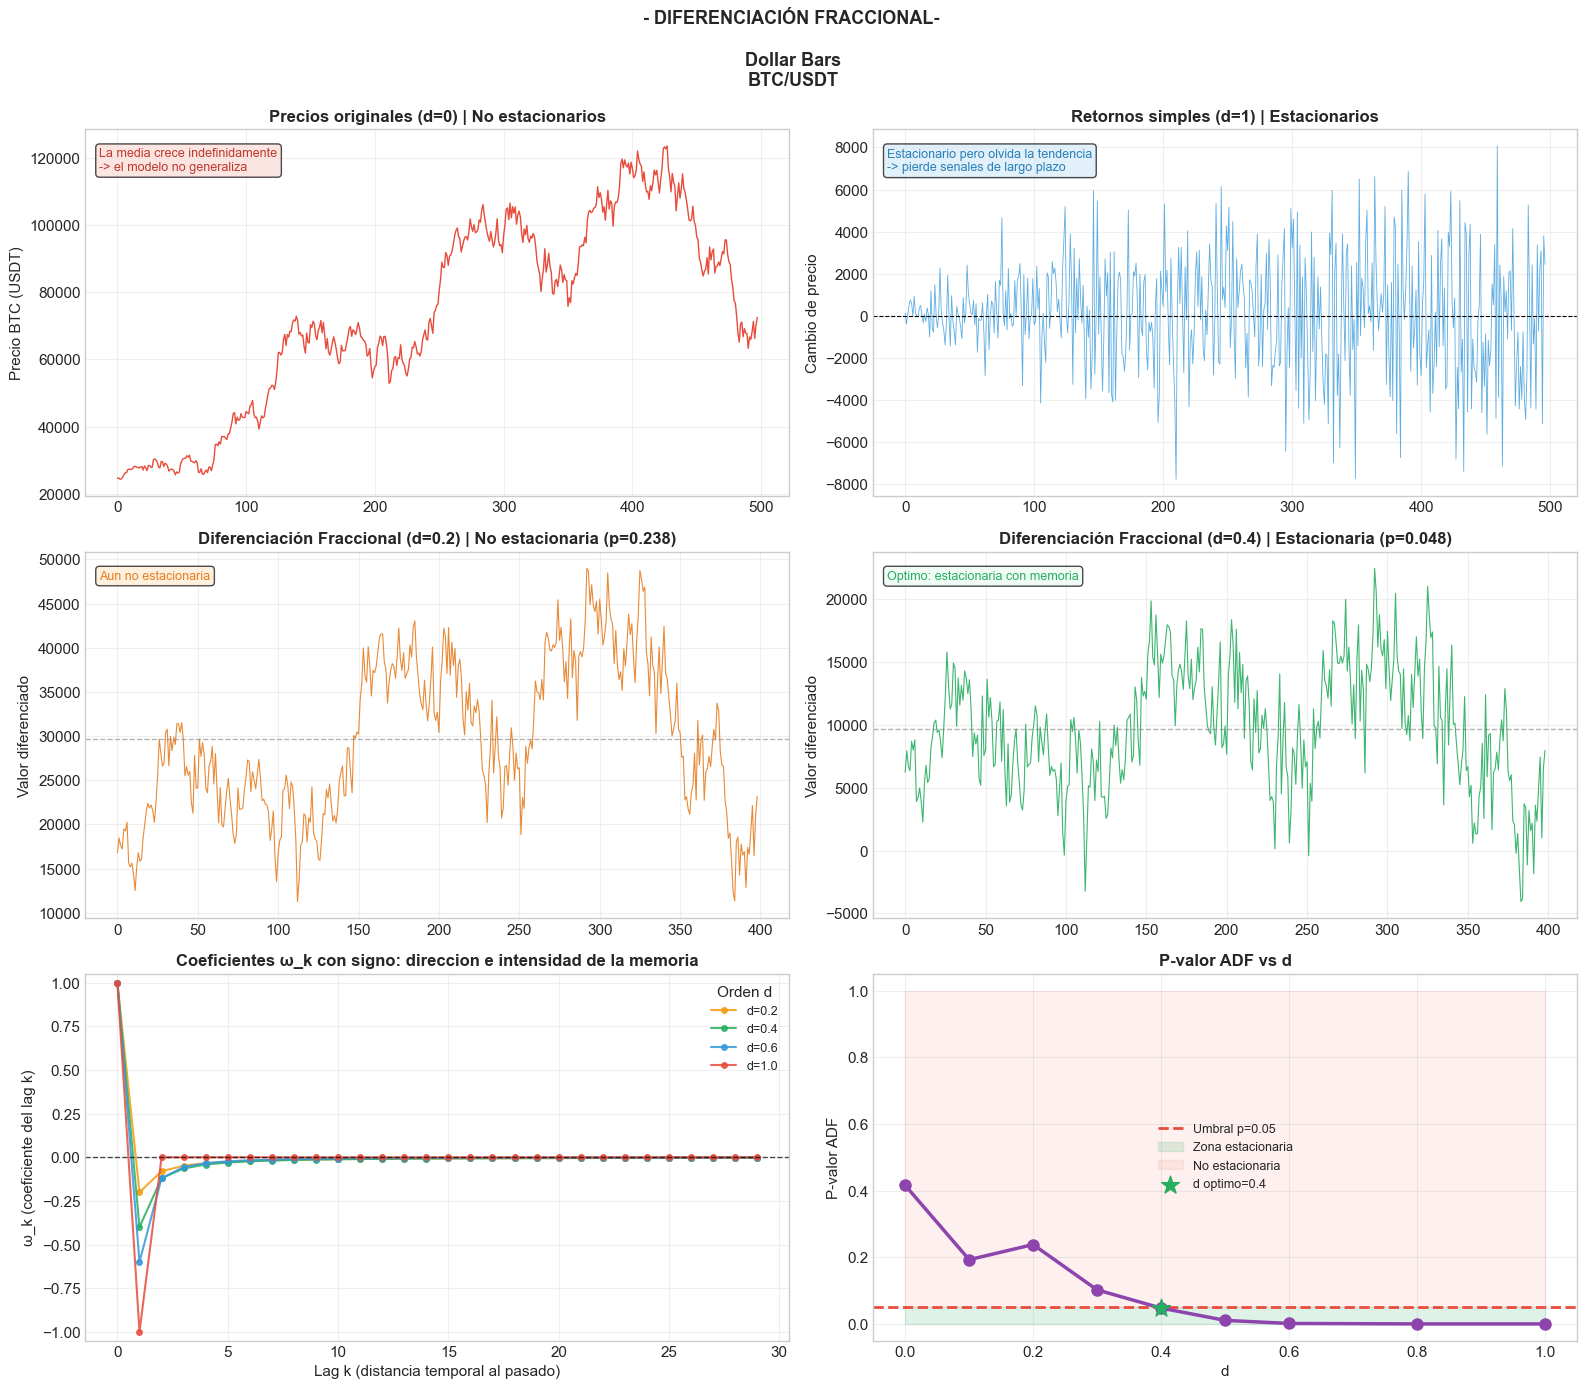

In [56]:
#  VISUALIZACION: DIFRENCIACIÓN FRACCIONAL

fig, axes = plt.subplots(3, 2, figsize=(16, 14))
fig.suptitle('- DIFERENCIACIÓN FRACCIONAL- \n\nDollar Bars\nBTC/USDT',
             fontsize=13, fontweight='bold', y=0.99)

# Panel 1: precio original
ax = axes[0, 0]
ax.plot(range(len(close)), close.values, color='#E74C3C', lw=1)
ax.set_title('Precios originales (d=0) | No estacionarios')
ax.set_ylabel('Precio BTC (USDT)')
ax.text(0.02, 0.95, 'La media crece indefinidamente\n-> el modelo no generaliza',
        transform=ax.transAxes, fontsize=9, va='top', color="#C0392B",
        bbox=dict(boxstyle='round', facecolor='#FADBD8', alpha=0.7))
ax.grid(True, alpha=0.3)

# Panel 2: retornos simples (d=1)
ax = axes[0, 1]
ret_s = close.diff().dropna()
ax.plot(range(len(ret_s)), ret_s.values, color='#3498DB', lw=0.6, alpha=0.8)
ax.axhline(0, color='black', lw=0.8, ls='--')
ax.set_title('Retornos simples (d=1) | Estacionarios')
ax.set_ylabel('Cambio de precio')
ax.text(0.02, 0.95, 'Estacionario pero olvida la tendencia\n-> pierde senales de largo plazo',
        transform=ax.transAxes, fontsize=9, va='top', color='#2980B9',
        bbox=dict(boxstyle='round', facecolor='#D6EAF8', alpha=0.7))
ax.grid(True, alpha=0.3)

# Paneles 3-4: fracdiff con d=0.2 y d_optimo
for ax, d_val in [(axes[1, 0], 0.2), (axes[1, 1], d_optimo)]:
    fd = series_fd.get(d_val, aplicar_fracdiff(close, d=d_val))
    pv = pvalores_d.get(d_val, 1.0)
    ok = pv < 0.05
    c = '#27AE60' if ok else '#E67E22'
    ax.plot(range(len(fd)), fd.values, color=c, lw=0.8, alpha=0.9)
    ax.axhline(fd.mean(), color='gray', lw=1, ls='--', alpha=0.6, label='Media')
    ax.set_title(f'Diferenciación Fraccional (d={d_val}) | {"Estacionaria" if ok else "No estacionaria"} (p={pv:.3f})')
    ax.set_ylabel('Valor diferenciado')
    label = ('Optimo: estacionaria con memoria' if ok else 'Aun no estacionaria')
    ax.text(0.02, 0.95, label, transform=ax.transAxes, fontsize=9, va='top', color=c,
            bbox=dict(boxstyle='round', facecolor='#EAFAF1' if ok else '#FDEBD0', alpha=0.7))
    ax.grid(True, alpha=0.3)

# Panel 5: coeficientes omega_k con signo para distintos d
ax = axes[2, 0]
for d_p, cp in [(0.2, '#F39C12'), (0.4, '#27AE60'), (0.6, '#3498DB'), (1.0, '#E74C3C')]:
    w = calcular_pesos(d_p, max_lag=30)
    w_f = np.zeros(30)
    w_f[:len(w)] = w  # mantenemos el signo para ver la direccion de cada coeficiente
    ax.plot(range(30), w_f, 'o-', color=cp, lw=1.5, ms=4, label=f'd={d_p}', alpha=0.85)
ax.axhline(0, color='black', lw=1.0, ls='--', alpha=0.7)
ax.set_title('Coeficientes ω_k con signo: direccion e intensidad de la memoria')
ax.set_xlabel('Lag k (distancia temporal al pasado)')
ax.set_ylabel('ω_k (coeficiente del lag k)')
ax.set_ylim(-1.05, 1.05)
ax.legend(fontsize=9, title='Orden d')
ax.grid(True, alpha=0.3)

# Panel 6: curva p-valor ADF vs d
ax = axes[2, 1]
ds_p = sorted(pvalores_d.keys())
pvs_p = [pvalores_d[d] for d in ds_p]
ax.plot(ds_p, pvs_p, 'o-', color='#8E44AD', lw=2.5, ms=8, zorder=5)
ax.axhline(0.05, color='#E74C3C', lw=2, ls='--', label='Umbral p=0.05')
ax.fill_between(ds_p, 0, 0.05, alpha=0.15, color='#27AE60', label='Zona estacionaria')
ax.fill_between(ds_p, 0.05, 1.0, alpha=0.08, color='#E74C3C', label='No estacionaria')
if d_optimo in pvalores_d:
    ax.scatter([d_optimo], [pvalores_d[d_optimo]], s=180, color='#27AE60',
               zorder=10, marker='*', label=f'd optimo={d_optimo}')
ax.set_title('P-valor ADF vs d')
ax.set_xlabel('d')
ax.set_ylabel('P-valor ADF')
ax.set_ylim(-0.05, 1.05)
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('t2_fracdiff.png', dpi=130, bbox_inches='tight')
print('Visualización de resultados:')
plt.show()

> <u>Comentario</u>: los gráficos anteriores aportan infromación sobre la diferenciación fraccional elaborada.
>
> - Los primeros cuatro gráficos muestran la progresión desde los precios originales (d=0), con una tendencia no estacionaria que impide la generalización, hasta los retornos simples (d=1), estacionarios pero sin memoria. Entre ambos extremos, d=0.2 aún no alcanza estacionariedad (p=0.238), mientras que d=0.4 la consigue (p=0.048) preservando oscilaciones de mayor amplitud que los retornos puros, reflejo de la memoria de largo plazo retenida.
>
> - El panel de coeficientes ω muestra cómo, para d bajos (0.2, 0.4), los pesos decaen gradualmente sin anularse, lo que permite que cada observación incorpore información de su pasado lejano con influencia decreciente. Para d=1.0, en cambio, solo sobreviven ω₀ y ω₁, descartando todo el historial previo.
>
> - El panel de p-valor ADF vs d confirma que d=0.4 es el mínimo orden de diferenciación que cruza el umbral de estacionariedad (p < 0.05). Diferenciar más allá de ese punto destruye memoria sin ganancia estadística adicional.

#### **3.3.1. Anexo: Escala vs. Estructura**

La serie fraccional con d=0.4 conserva magnitudes visualmente altas en escala original, lo que puede dar la impresión de que apenas difiere del precio. Este anexo normaliza las tres series a z-score y compara su función de autocorrelación (ACF) para verificar que el cambio es estructural, no solo de escala.

Anexo: escala vs. estructura


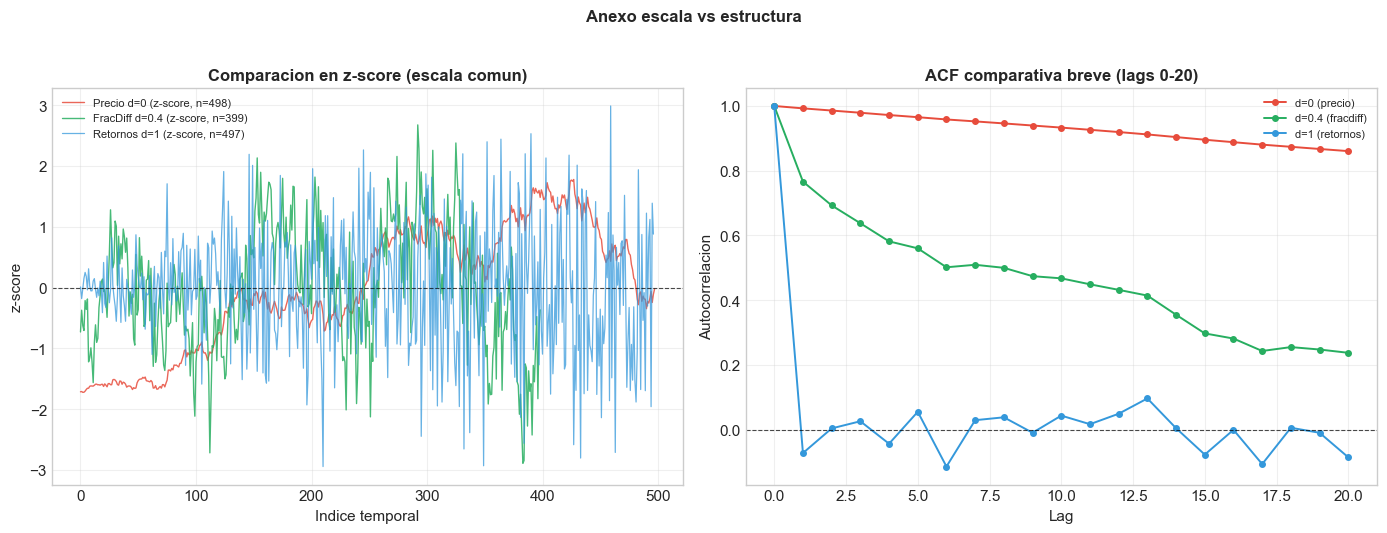

In [54]:
# ANEXO: ESCALA VS ESTRUCTURA
# Figura compacta para reforzar interpretacion
from statsmodels.tsa.stattools import acf


def zscore_serie(s):
    """Estandariza una serie para comparar forma sin sesgo de escala."""
    s = s.dropna()
    sd = s.std(ddof=0)
    if sd == 0 or np.isnan(sd):
        return pd.Series(np.zeros(len(s)), index=s.index)
    return (s - s.mean()) / sd


fd_opt = series_fd.get(d_optimo, aplicar_fracdiff(close, d=d_optimo))
z_orig = zscore_serie(close)
z_fd = zscore_serie(fd_opt)
z_ret = zscore_serie(ret_s)

fig2, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5.2))
fig2.suptitle('Anexo escala vs estructura',
              fontsize=12, fontweight='bold', y=1.02)

# Anexo panel 1: comparacion en z-score
ax1.plot(range(len(z_orig)), z_orig.values, color='#E74C3C', lw=1.0, alpha=0.85,
         label=f'Precio d=0 (z-score, n={len(z_orig)})')
ax1.plot(range(len(z_fd)), z_fd.values, color='#27AE60', lw=1.0, alpha=0.85,
         label=f'FracDiff d={d_optimo} (z-score, n={len(z_fd)})')
ax1.plot(range(len(z_ret)), z_ret.values, color='#3498DB', lw=0.9, alpha=0.75,
         label=f'Retornos d=1 (z-score, n={len(z_ret)})')
ax1.axhline(0, color='black', lw=0.8, ls='--', alpha=0.7)
ax1.set_title('Comparacion en z-score (escala comun)')
ax1.set_xlabel('Indice temporal')
ax1.set_ylabel('z-score')
ax1.legend(fontsize=8)
ax1.grid(True, alpha=0.3)

# Anexo panel 2: ACF comparativa breve
lags = np.arange(0, 21)
acf_orig = acf(close.dropna(), nlags=20, fft=False)
acf_fd = acf(fd_opt.dropna(), nlags=20, fft=False)
acf_ret = acf(ret_s.dropna(), nlags=20, fft=False)

ax2.plot(lags, acf_orig, 'o-', color='#E74C3C', lw=1.4, ms=4, label='d=0 (precio)')
ax2.plot(lags, acf_fd, 'o-', color='#27AE60', lw=1.4, ms=4, label=f'd={d_optimo} (fracdiff)')
ax2.plot(lags, acf_ret, 'o-', color='#3498DB', lw=1.4, ms=4, label='d=1 (retornos)')
ax2.axhline(0, color='black', lw=0.8, ls='--', alpha=0.7)
ax2.set_title('ACF comparativa breve (lags 0-20)')
ax2.set_xlabel('Lag')
ax2.set_ylabel('Autocorrelacion')
ax2.legend(fontsize=8)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('t2_fracdiff_anexo_escala_estructura.png', dpi=130, bbox_inches='tight')
print('Anexo: escala vs. estructura')
plt.show()

> <u>Comentario</u>:
>
> - En el panel de z-score, la serie fraccional (d=0.4) presenta una variabilidad comparable a la de los retornos (d=1), confirmando que la magnitud alta observada en escala original es un efecto de nivel, no de estructura. El precio (d=0), en cambio, mantiene una tendencia clara incluso tras la normalización.
>
> - La ACF cuantifica directamente la memoria preservada. El precio (d=0) muestra una autocorrelación que apenas decae desde 1.0, típica de una serie no estacionaria. Los retornos (d=1) colapsan a cero desde el primer lag, sin memoria. La serie fraccional (d=0.4) se sitúa entre ambos: parte de 1.0 y decae gradualmente hasta ~0.25 en lag 20, reflejando la memoria de largo plazo que la diferenciación fraccional conserva por diseño.

## <font color=#0099CC>**4. LIMPIEZA DE MATRIZ DE COVARIANZA (MARCHENKO-PASTUR)**</font>

La matriz de covarianza empírica de un universo multi-activo contiene ruido estadístico que distorsiona las correlaciones reales. Se aplica la teoría de matrices aleatorias (Marchenko-Pastur) para separar señal de ruido, y las técnicas de *denoise* y *detone* para obtener matrices más estables y robustas.

### <font color=#336699>**4.1. ¿Por Qué la Matriz de Covarianza Empírica Contiene Ruido?**</font>

Cuando trabajamos con un universo de varios activos, la **matriz de covarianza** es la pieza central para entender cómo se mueven conjuntamente sus retornos. Es la base de la construcción de carteras, la gestión de riesgo y la estimación de factores comunes. Sin embargo, la matriz que calculamos a partir de datos históricos no refleja con exactitud la estructura real de dependencias entre activos: parte de lo que observamos es señal genuina y parte es ruido estadístico.

Este problema se agrava cuando el número de observaciones temporales (*T*) no es suficientemente grande en relación al número de activos (*N*). En ese caso, la matriz contiene correlaciones espurias que aparecen por azar muestral, no porque exista una relación económica real entre los activos. Un modelo o una estrategia de portfolio que confíe en esas correlaciones espurias tomará decisiones basadas en artefactos estadísticos.

- <u>En esta práctica</u>: trabajamos con 5 activos cripto (BTC, ETH, BNB, SOL, XRP) y ~315.000 observaciones de 5 minutos. Aunque el ratio *q = T/N* es muy favorable, el ejercicio permite ilustrar la metodología de limpieza y validar que las correlaciones observadas son robustas y no artefactos del muestreo.


### <font color=#336699>**4.2. Solución: Marchenko-Pastur + Denoise + Detone**</font>

La teoría de matrices aleatorias (RMT) proporciona un criterio objetivo para separar señal de ruido en una matriz de correlación. El resultado central es la **distribución de Marchenko-Pastur**, que describe cómo se distribuyen los eigenvalores de una matriz de correlación generada por datos puramente aleatorios (sin estructura). Cualquier eigenvalor empírico que caiga dentro de esta distribución teórica es indistinguible del ruido; solo los que la superan contienen señal real.

El umbral máximo de la distribución de ruido viene dado por:

$$\lambda_{max} = \left(1 + \frac{1}{\sqrt{q}}\right)^2, \quad q = T/N$$

donde *T* es el número de observaciones y *N* el número de activos. A partir de este umbral se aplican dos operaciones de limpieza:

- **Denoise:** los eigenvalores que caen por debajo de $\lambda_{max}$ se consideran ruido y se reemplazan por su media, estabilizando la matriz sin eliminar información relevante. Esto reduce la influencia de correlaciones espurias y produce una matriz más robusta para la estimación de riesgo.

- **Detone:** se elimina el primer eigenvalor (el mayor), que normalmente captura el **factor de mercado común** (el movimiento conjunto de todos los activos). Al quitarlo, la matriz resultante refleja las dependencias *relativas* entre activos, lo que resulta útil para detectar estructura de clusters o relaciones específicas entre pares que quedan ocultas por el movimiento general del mercado.

Finalmente, a partir de las matrices de correlación limpias se reconstruyen las **covarianzas limpias**, directamente utilizables en optimización de carteras y análisis de riesgo.


#### **4.2.1. Limpieza de Matriz de Covarianza (Multi-Activo)**

In [70]:
# LIMPIEZA DE MATRIZ DE COVARIANZA (MULTI-ACTIVO)
# Input: datos_multi_close (BTC, ETH, BNB, SOL, XRP en 5m sincronizado)

activos_t3 = SYMBOLS.copy()

# Cierres sincronizados entre activos (mismo timestamp en todas las columnas).
close_t3 = datos_multi_close[activos_t3].copy()

# Matriz de retornos logarítmicos R (T x N): filas=tiempo, columnas=activos.
R = np.log(close_t3).diff()
R = R.replace([np.inf, -np.inf], np.nan).dropna()

if R.empty:
    raise ValueError('La matriz de retornos R quedó vacía tras limpiar NaN/inf.')

T, N = R.shape
q = T / N
if q <= 1:
    raise ValueError(f'Se necesita q=T/N > 1 para MP. Valor actual: q={q:.3f}')

# Matrices empíricas de referencia.
corr_empirica = R.corr()
cov_empirica = R.cov()

# Eigenspectrum de la correlación empírica (orden descendente).
eigenvalores, eigenvectores = eigh(corr_empirica.values)
orden = eigenvalores.argsort()[::-1]
eigenvalores = eigenvalores[orden]
eigenvectores = eigenvectores[:, orden]

# Umbral de ruido Marchenko-Pastur (sigma^2=1 por trabajar con correlación).
lambda_max = (1 + 1 / np.sqrt(q)) ** 2
mascara_ruido = eigenvalores <= lambda_max
n_signal = int((~mascara_ruido).sum())
n_noise = int(mascara_ruido.sum())


def normalizar_correlacion(corr_np):
    """Fuerza diagonal unitaria y simetría numérica estable."""
    diag = np.maximum(np.diag(corr_np), 1e-12)
    corr_np = corr_np / np.sqrt(np.outer(diag, diag))
    corr_np = (corr_np + corr_np.T) / 2
    np.fill_diagonal(corr_np, 1.0)
    return corr_np


def denoise_mp(evals, evecs, mask_ruido):
    """
    Denoise MP:
    - preserva eigenvalores de señal
    - reemplaza eigenvalores de ruido por su media
    """
    evals_limpios = evals.copy()
    if mask_ruido.any():
        evals_limpios[mask_ruido] = evals_limpios[mask_ruido].mean()

    corr_np = evecs @ np.diag(evals_limpios) @ evecs.T
    corr_np = normalizar_correlacion(corr_np)

    corr_df = pd.DataFrame(corr_np, index=corr_empirica.index, columns=corr_empirica.columns)
    return corr_df, evals_limpios


def detone(corr_df, n_factores=1):
    """
    Detone:
    elimina el primer factor común (modo mercado) de la matriz de correlación.
    """
    evals, evecs = eigh(corr_df.values)
    orden = evals.argsort()[::-1]
    evals = evals[orden]
    evecs = evecs[:, orden]

    corr_np = corr_df.values.copy()
    for k in range(min(n_factores, len(evals))):
        corr_np -= evals[k] * np.outer(evecs[:, k], evecs[:, k])

    corr_np = normalizar_correlacion(corr_np)
    return pd.DataFrame(corr_np, index=corr_df.index, columns=corr_df.columns)


def corr_a_cov(corr_df, std_series):
    """Reconstruye covarianza a partir de correlación y desviaciones estándar."""
    escala = np.outer(std_series.values, std_series.values)
    cov_np = corr_df.values * escala
    return pd.DataFrame(cov_np, index=corr_df.index, columns=corr_df.columns)


def media_abs_fuera_diagonal(df):
    """Indicador compacto de dependencia promedio entre pares distintos."""
    vals = df.values.copy()
    np.fill_diagonal(vals, np.nan)
    return float(np.nanmean(np.abs(vals)))


# 1) Denoise de correlación
corr_denoised, eigenvalores_denoised = denoise_mp(eigenvalores, eigenvectores, mascara_ruido)

# 2) Detone sobre la correlación ya denoised
corr_detoned = detone(corr_denoised, n_factores=1)

# 3) Covarianzas: empírica y limpias
std_ret = R.std(ddof=1)
cov_denoised = corr_a_cov(corr_denoised, std_ret)
cov_detoned = corr_a_cov(corr_detoned, std_ret)

# Métricas de resumen para interpretación.
metricas_corr = {
    'Empírica': media_abs_fuera_diagonal(corr_empirica),
    'Denoised': media_abs_fuera_diagonal(corr_denoised),
    'Detoned': media_abs_fuera_diagonal(corr_detoned),
}

print('Resumen técnica 3 (multi-activo):')
print(f'  > Activos: {activos_t3}')
print(f'  > Observaciones: q = T/N = {T:,}/{N} = {q:.1f}')
print(f'  > Umbral de Marchenko-Pastur: λ_max = {lambda_max:.4f}')
print(f'  > Eigenvalores de señal: {n_signal}')
print(f'  > Eigenvalores de ruido: {n_noise}')
print(
    '  > Correlaicón fuera de diagonal: '
    f"empírica={metricas_corr['Empírica']:.4f} | "
    f"denoised={metricas_corr['Denoised']:.4f} | "
    f"detoned={metricas_corr['Detoned']:.4f}"
)


Resumen técnica 3 (multi-activo):
  > Activos: ['BTCUSDT', 'ETHUSDT', 'BNBUSDT', 'SOLUSDT', 'XRPUSDT']
  > Observaciones: q = T/N = 315,919/5 = 63183.8
  > Umbral de Marchenko-Pastur: λ_max = 1.0080
  > Eigenvalores de señal: 1
  > Eigenvalores de ruido: 4
  > Correlaicón fuera de diagonal: empírica=0.6632 | denoised=0.6635 | detoned=0.2499


#### **4.2.2. Visualización Multiactivo**

Se representan los eigenvalores empíricos frente al umbral teórico de Marchenko-Pastur, y las matrices de correlación original, *denoised* y *detoned* para evaluar el efecto de la limpieza.

Visualicación de correlaciones y covarianzas limpias (multiactivo):


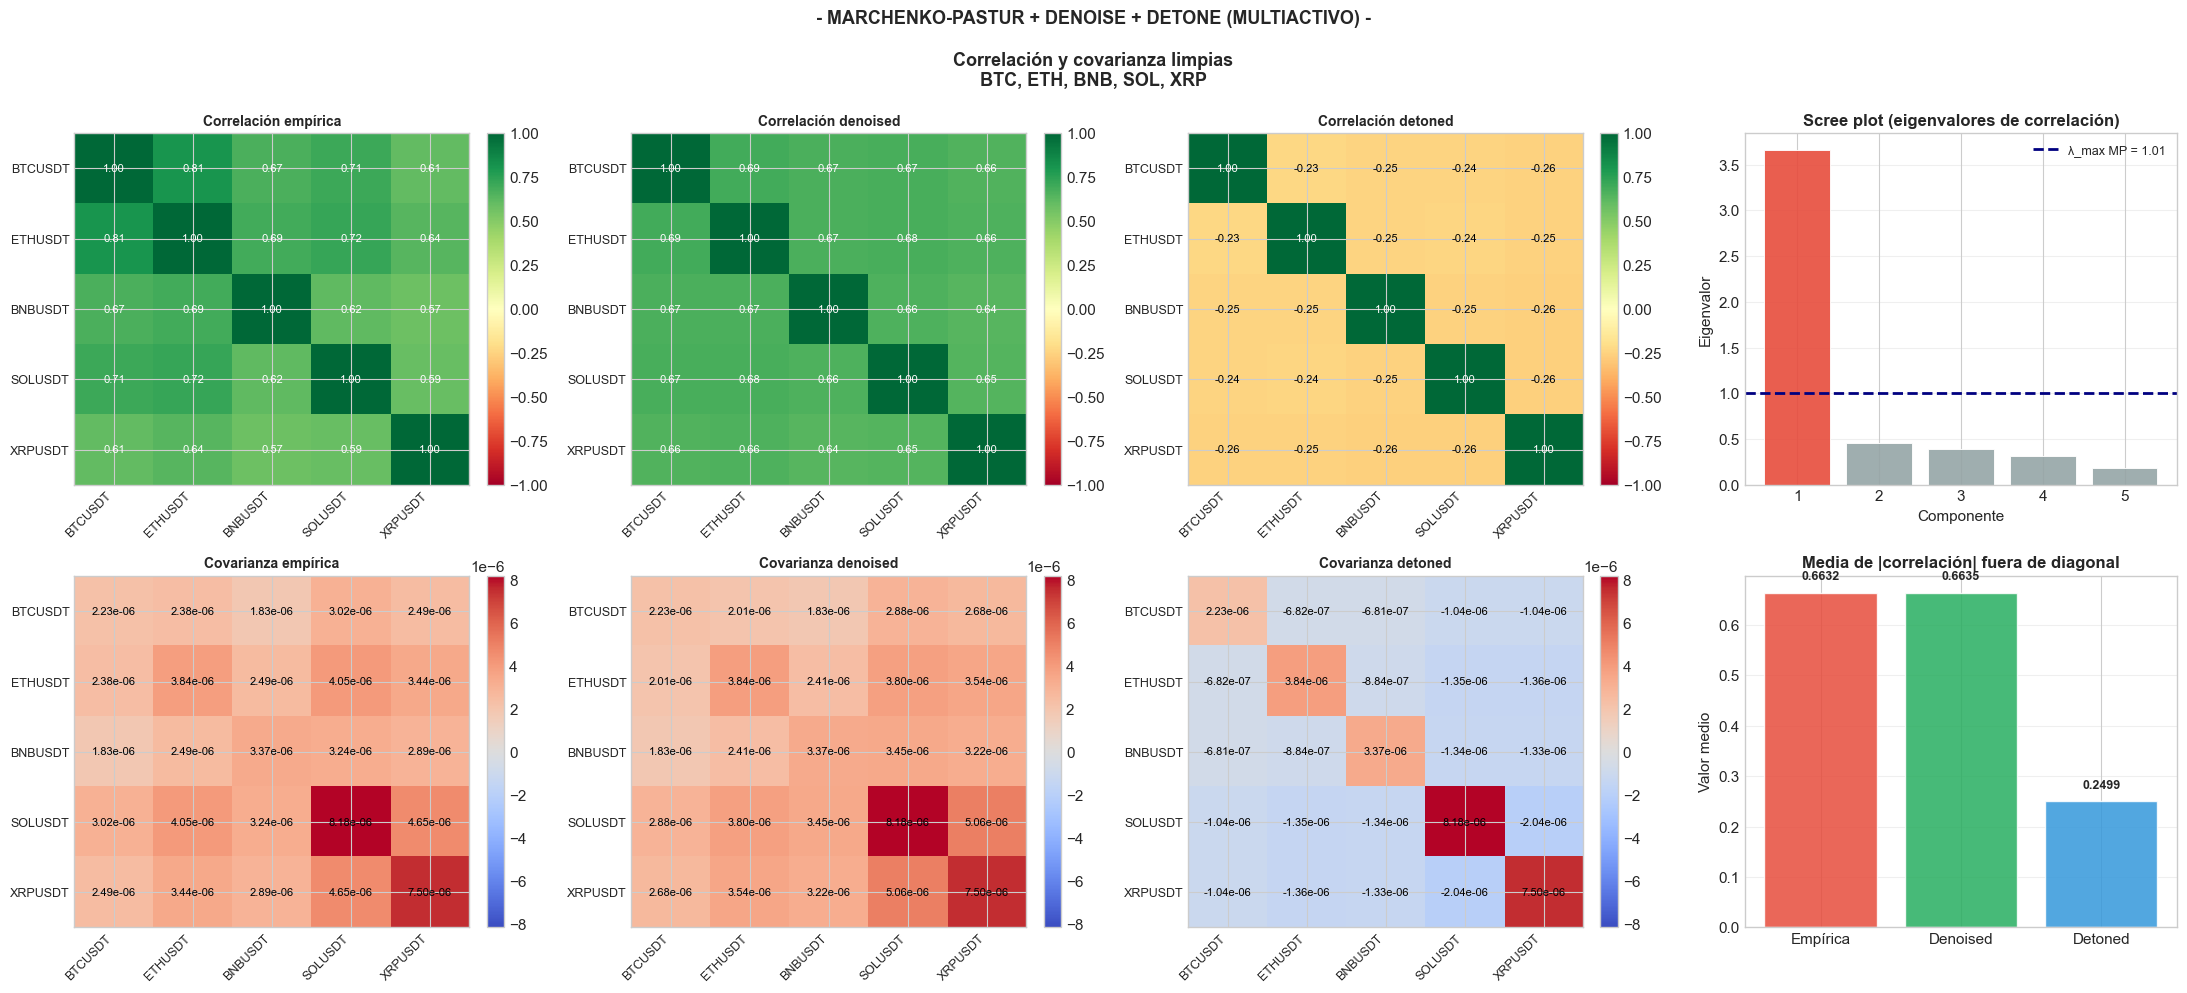

In [82]:
# VISUALIZACIÓN MULTI-ACTIVO
# Heatmaps: correlación/covarianza (empírica vs denoised vs detoned)
# Scree plot: eigenvalores y umbral Marchenko-Pastur

def plot_heatmap(ax, df, title, cmap, vmin, vmax, fmt='{:.2f}'):
    """Heatmap compacto con anotación para matrices pequeñas (N=5)."""
    im = ax.imshow(df.values, cmap=cmap, vmin=vmin, vmax=vmax, aspect='auto')
    ax.set_title(title, fontsize=10)
    ax.set_xticks(range(len(df.columns)))
    ax.set_xticklabels(df.columns, rotation=45, ha='right', fontsize=9)
    ax.set_yticks(range(len(df.index)))
    ax.set_yticklabels(df.index, fontsize=9)

    for i in range(df.shape[0]):
        for j in range(df.shape[1]):
            valor = df.values[i, j]
            color = 'white' if abs(valor) > 0.5 else 'black'
            ax.text(j, i, fmt.format(valor), ha='center', va='center', fontsize=8, color=color)

    return im


fig, axes = plt.subplots(2, 4, figsize=(22, 10))
fig.suptitle(
    '- MARCHENKO-PASTUR + DENOISE + DETONE (MULTIACTIVO) -\n'
    '\nCorrelación y covarianza limpias\nBTC, ETH, BNB, SOL, XRP',
    fontsize=13,
    fontweight='bold',
    y=0.99,
)

# Fila 1: correlaciones + scree plot
im0 = plot_heatmap(
    axes[0, 0],
    corr_empirica,
    'Correlación empírica',
    cmap='RdYlGn',
    vmin=-1,
    vmax=1,
    fmt='{:.2f}',
)
plt.colorbar(im0, ax=axes[0, 0], fraction=0.046, pad=0.04)

im1 = plot_heatmap(
    axes[0, 1],
    corr_denoised,
    'Correlación denoised',
    cmap='RdYlGn',
    vmin=-1,
    vmax=1,
    fmt='{:.2f}',
)
plt.colorbar(im1, ax=axes[0, 1], fraction=0.046, pad=0.04)

im2 = plot_heatmap(
    axes[0, 2],
    corr_detoned,
    'Correlación detoned',
    cmap='RdYlGn',
    vmin=-1,
    vmax=1,
    fmt='{:.2f}',
)
plt.colorbar(im2, ax=axes[0, 2], fraction=0.046, pad=0.04)

ax_scree = axes[0, 3]
x = np.arange(1, N + 1)
colores_eig = [COLORS['signal'] if ev > lambda_max else COLORS['noise'] for ev in eigenvalores]
ax_scree.bar(x, eigenvalores, color=colores_eig, alpha=0.9, edgecolor='white', lw=0.7)
ax_scree.axhline(lambda_max, color='navy', ls='--', lw=2, label=f'λ_max MP = {lambda_max:.2f}')
ax_scree.set_title('Scree plot (eigenvalores de correlación)')
ax_scree.set_xlabel('Componente')
ax_scree.set_ylabel('Eigenvalor')
ax_scree.set_xticks(x)
ax_scree.legend(fontsize=9)
ax_scree.grid(True, alpha=0.3, axis='y')


# Fila 2: covarianzas + resumen de dependencia media
cov_abs_max = float(
    max(
        np.abs(cov_empirica.values).max(),
        np.abs(cov_denoised.values).max(),
        np.abs(cov_detoned.values).max(),
    )
)

im3 = plot_heatmap(
    axes[1, 0],
    cov_empirica,
    'Covarianza empírica',
    cmap='coolwarm',
    vmin=-cov_abs_max,
    vmax=cov_abs_max,
    fmt='{:.2e}',
)
plt.colorbar(im3, ax=axes[1, 0], fraction=0.046, pad=0.04)

im4 = plot_heatmap(
    axes[1, 1],
    cov_denoised,
    'Covarianza denoised',
    cmap='coolwarm',
    vmin=-cov_abs_max,
    vmax=cov_abs_max,
    fmt='{:.2e}',
)
plt.colorbar(im4, ax=axes[1, 1], fraction=0.046, pad=0.04)

im5 = plot_heatmap(
    axes[1, 2],
    cov_detoned,
    'Covarianza detoned',
    cmap='coolwarm',
    vmin=-cov_abs_max,
    vmax=cov_abs_max,
    fmt='{:.2e}',
)
plt.colorbar(im5, ax=axes[1, 2], fraction=0.046, pad=0.04)

ax_m = axes[1, 3]
nombres = list(metricas_corr.keys())
valores = [metricas_corr[k] for k in nombres]
ax_m.bar(nombres, valores, color=['#E74C3C', '#27AE60', '#3498DB'], alpha=0.85, edgecolor='white')
for i, v in enumerate(valores):
    ax_m.text(i, v + max(valores) * 0.03, f'{v:.4f}', ha='center', va='bottom', fontsize=9, fontweight='bold')
ax_m.set_title('Media de |correlación| fuera de diagonal')
ax_m.set_ylabel('Valor medio')
ax_m.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('t3_covarianza_multiactivo.png', dpi=130, bbox_inches='tight')
print('Visualicación de correlaciones y covarianzas limpias (multiactivo):')
plt.show()

> <u>Comentario</u>:
>
> - La **correlación empírica** muestra que los 5 activos están muy correlacionados entre sí, lo que sugiere que un único factor común domina el co-movimiento. El **scree plot** lo confirma: el primer eigenvalor (~3.5) concentra la mayor parte de la varianza y supera ampliamente el umbral teórico de Marchenko-Pastur (λ_max ≈ 1.01), mientras que los 4 restantes quedan por debajo. Esto no es una anomalía: en un universo de criptomonedas altamente correlacionadas, es esperable que exista un único factor dominante (el mercado cripto) y que los demás eigenvalores sean residuales.
>
> - El **denoise** apenas modifica la matriz (la media de |correlación| fuera de diagonal pasa de 0.6632 a 0.6635). Aunque 4 de 5 eigenvalores caen técnicamente en la zona de ruido, el primer eigenvalor domina de forma tan abrumadora la estructura de la matriz (3.5 de un total de 5) que reemplazar los menores por su media apenas altera el resultado reconstruido. La escasa diferencia confirma que la estructura de correlación observada está determinada casi en su totalidad por el factor de mercado.
>
> - El **detone**, en cambio, transforma la estructura de forma sustancial: la media de |correlación| cae de 0.66 a 0.25, y aparecen correlaciones negativas entre pares de activos. Al eliminar el primer eigenvalor (el modo de mercado), se revelan las dependencias *relativas* entre activos, que estaban enmascaradas por el movimiento conjunto. Esta información es relevante para estrategias de valor relativo o pair trading, donde interesa saber cómo se comportan los activos entre sí una vez descontado el efecto del mercado global.

### <font color=#336699>**4.3. Extensión: Limpieza de Covarianzas sobre Features de BTC**</font>

En el apartado anterior se ha aplicado la limpieza de Marchenko-Pastur a un universo **multi-activo** (N=5 criptomonedas, T~315.000 observaciones), un régimen estadístico en el que el ratio *q = T/N* es muy alto. Sin embargo, dado que los 5 activos cripto están dominados por un único factor de mercado, solo el primer eigenvalor supera el umbral teórico de ruido, y el denoise tiene un efecto marginal. En ese escenario, la operación más reveladora es el **detone**, que elimina ese factor dominante y permite observar las dependencias relativas entre activos.

Sin embargo, la limpieza de covarianza no solo es útil para carteras multi-activo: también se aplica a matrices de **features dentro de un mismo activo**. En esta extensión se construyen features de BTC a distintas escalas temporales (retornos, volatilidades, momentos a varios horizontes) y se calcula su matriz de correlación. Ahora el régimen estadístico es diferente: *N* (número de features) crece mientras *T* se mantiene, lo que reduce el ratio *q* y aumenta la proporción de eigenvalores contaminados por ruido.

- <u>En esta práctica</u>: al pasar de 5 activos a un conjunto más amplio de features intra-activo, el efecto del **denoise** se vuelve más visible que en el caso multi-activo. Esto se debe a que, con un *q* menor, más eigenvalores caen dentro de la distribución de Marchenko-Pastur y son reemplazados por su media, produciendo un cambio más apreciable en la matriz limpia.

Esta extensión complementa el análisis anterior mostrando que la misma metodología opera en dos contextos distintos: limpieza **cross-sectional** (entre activos) para gestión de riesgo y construcción de carteras, y limpieza de **features** (dentro de un activo) para mejorar la calidad de los inputs de modelos predictivos.

Resumen tecnica 3-B (BTC features):
  > Shape features: q = T/N = 399/12 = 33.2
  > Umbral MP: lambda_max = 1.3769 | Señal = 3 | Ruido = 9
  > Correlación fuera de diagonal: empirica = 0.3146 | denoised = 0.3234 | detoned = 0.3140


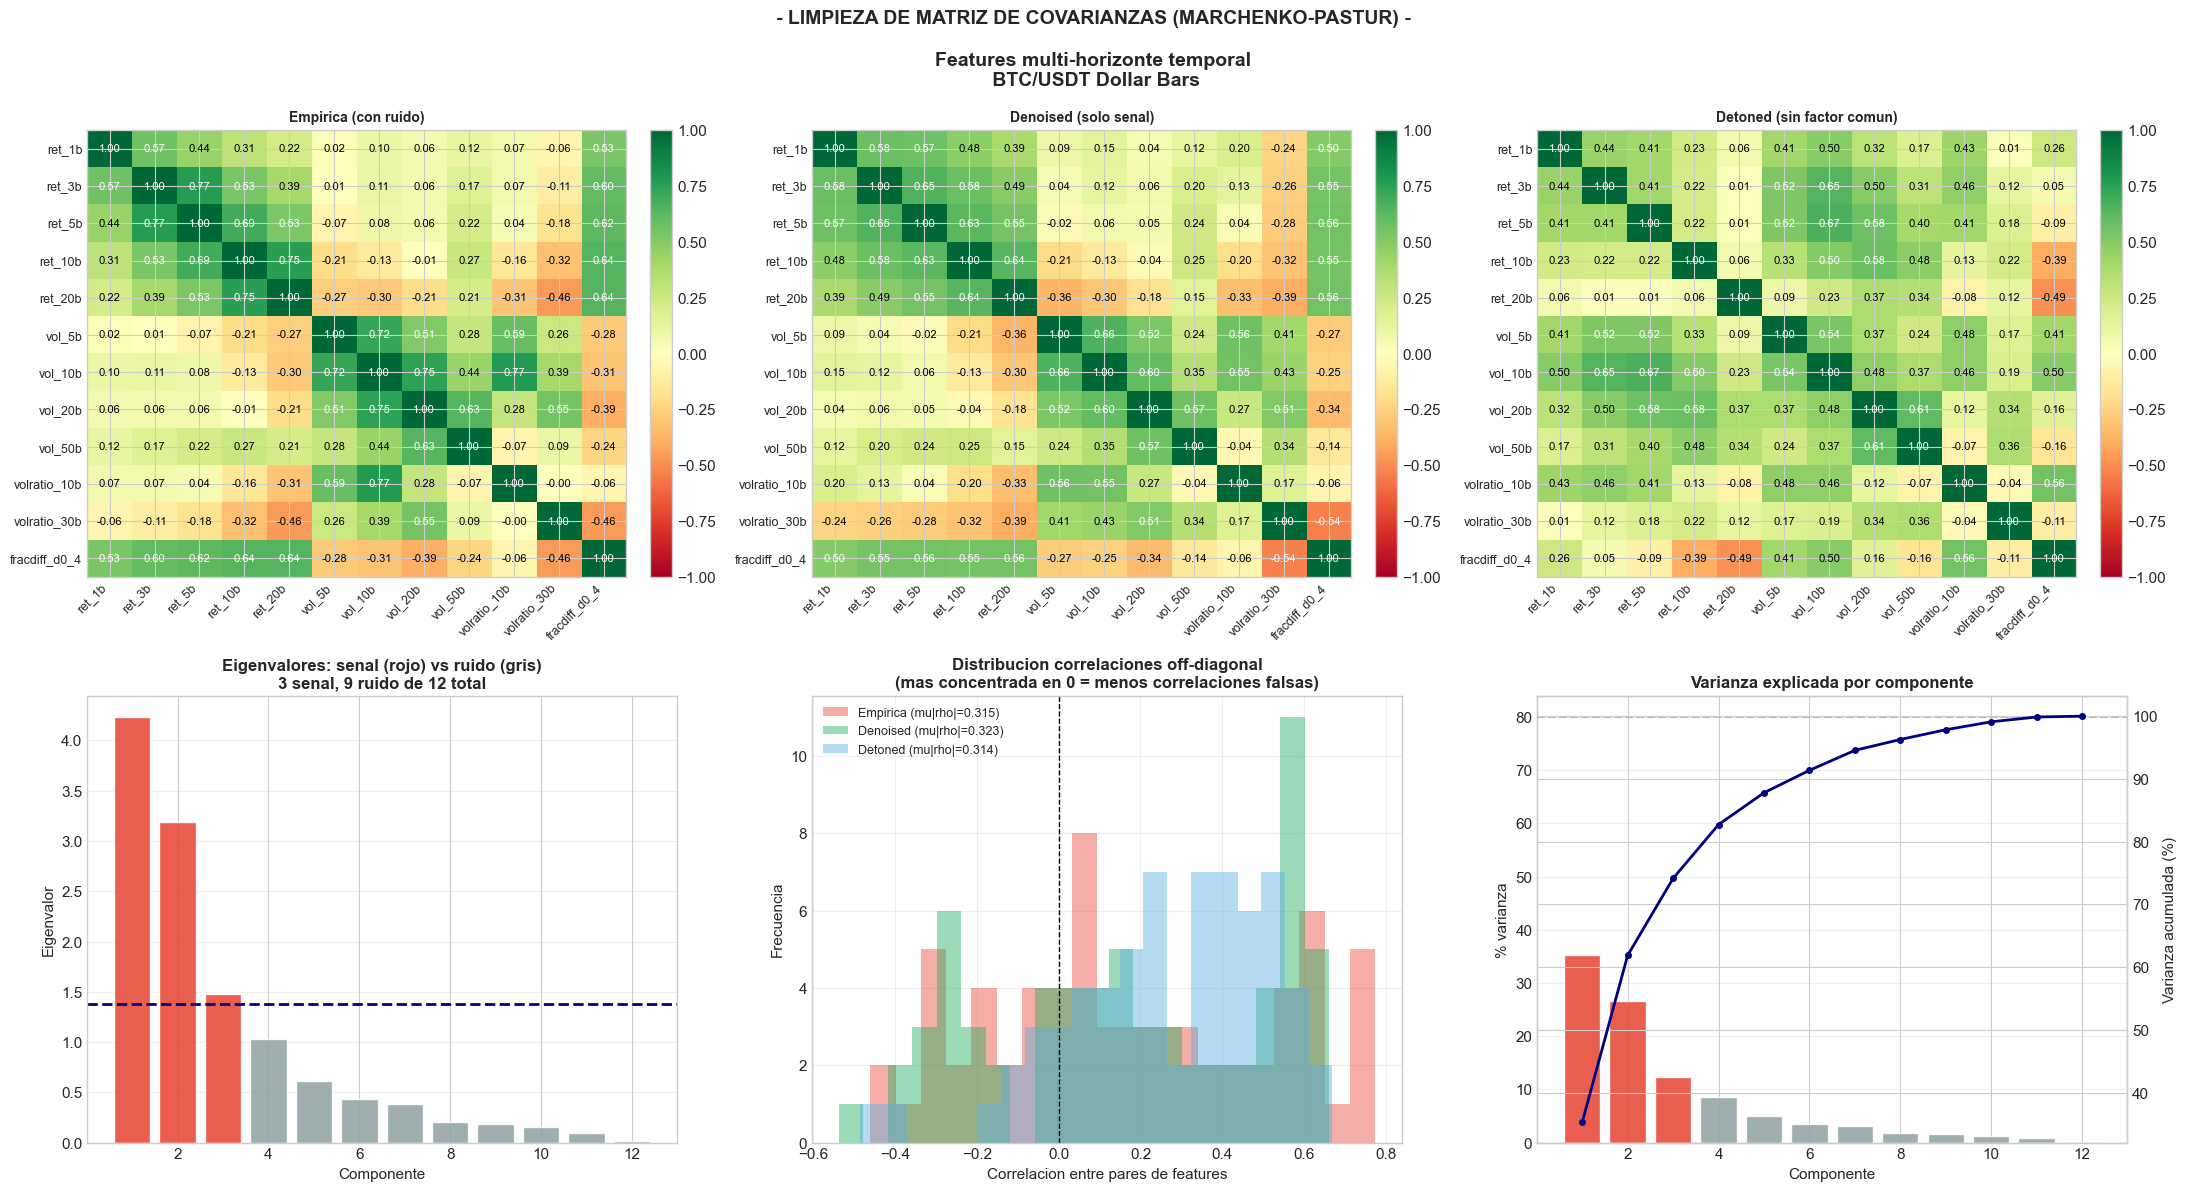

In [80]:
# LIMPIEZA DE COVARIANZA SOBRE FEATURES DE BTC (DOLLAR BARS)
# Mantiene intacto T3 multi-activo y anade un caso complementario para T5.

# 1) Construccion de features multi-horizonte sobre BTC.
close_btc_t3 = dollar_bars['close'].dropna().copy()
ret_1b = np.log(close_btc_t3).diff()
btc_feat_df = pd.DataFrame(index=close_btc_t3.index)
btc_feat_df['ret_1b'] = ret_1b
btc_feat_df['ret_3b'] = np.log(close_btc_t3).diff(3)
btc_feat_df['ret_5b'] = np.log(close_btc_t3).diff(5)
btc_feat_df['ret_10b'] = np.log(close_btc_t3).diff(10)
btc_feat_df['ret_20b'] = np.log(close_btc_t3).diff(20)
btc_feat_df['vol_5b'] = ret_1b.rolling(5).std()
btc_feat_df['vol_10b'] = ret_1b.rolling(10).std()
btc_feat_df['vol_20b'] = ret_1b.rolling(20).std()
btc_feat_df['vol_50b'] = ret_1b.rolling(50).std()
# Ratios de volatilidad para capturar cambios de regimen.
vol_10 = ret_1b.rolling(10).std()
vol_30 = ret_1b.rolling(30).std()
vol_60 = ret_1b.rolling(60).std()
btc_feat_df['volratio_10b'] = vol_10 / (vol_30 + 1e-12)
btc_feat_df['volratio_30b'] = vol_30 / (vol_60 + 1e-12)
# FracDiff optima de T2 como feature de memoria larga.
col_fd = f'fracdiff_d{d_optimo:.1f}'.replace('.', '_')
btc_feat_df[col_fd] = serie_fd_optima.reindex(btc_feat_df.index)
btc_feat_df = btc_feat_df.replace([np.inf, -np.inf], np.nan).dropna().copy()
if btc_feat_df.empty:
    raise ValueError('btc_feat_df quedo vacia tras limpieza de NaN/inf.')
# 2) Limpieza MP (denoise/detone) sobre la matriz de correlacion de features.
T_btc, N_btc = btc_feat_df.shape
q_btc = T_btc / N_btc
if q_btc <= 1:
    raise ValueError(f'Se requiere q=T/N > 1 en T3-B. Valor actual: q={q_btc:.3f}')
corr_btc_emp = btc_feat_df.corr()
cov_btc_emp = btc_feat_df.cov()
evals_btc, evecs_btc = eigh(corr_btc_emp.values)
ord_btc = evals_btc.argsort()[::-1]
evals_btc = evals_btc[ord_btc]
evecs_btc = evecs_btc[:, ord_btc]
lambda_max_btc = (1 + 1 / np.sqrt(q_btc)) ** 2
mask_noise_btc = evals_btc <= lambda_max_btc
n_signal_btc = int((~mask_noise_btc).sum())
n_noise_btc = int(mask_noise_btc.sum())
def denoise_mp_generic(evals, evecs, mask_noise):
    evals_clean = evals.copy()
    if mask_noise.any():
        evals_clean[mask_noise] = evals[mask_noise].mean()
    corr_np = evecs @ np.diag(evals_clean) @ evecs.T
    return normalizar_correlacion(corr_np)


def detone_corr_generic(evals, evecs, corr_np):
    if len(evals) == 0:
        return corr_np.copy()
    primer_factor = evals[0] * np.outer(evecs[:, 0], evecs[:, 0])
    corr_detoned_np = corr_np - primer_factor
    return normalizar_correlacion(corr_detoned_np)


corr_btc_denoised_np = denoise_mp_generic(evals_btc, evecs_btc, mask_noise_btc)
corr_btc_detoned_np = detone_corr_generic(evals_btc, evecs_btc, corr_btc_denoised_np)
corr_btc_denoised = pd.DataFrame(corr_btc_denoised_np, index=btc_feat_df.columns, columns=btc_feat_df.columns)
corr_btc_detoned = pd.DataFrame(corr_btc_detoned_np, index=btc_feat_df.columns, columns=btc_feat_df.columns)
std_btc = np.sqrt(np.maximum(np.diag(cov_btc_emp.values), 1e-12))
D_btc = np.diag(std_btc)
cov_btc_denoised = pd.DataFrame(D_btc @ corr_btc_denoised.values @ D_btc, index=btc_feat_df.columns, columns=btc_feat_df.columns)
cov_btc_detoned = pd.DataFrame(D_btc @ corr_btc_detoned.values @ D_btc, index=btc_feat_df.columns, columns=btc_feat_df.columns)
def abs_offdiag(df):
    m = df.values.copy()
    np.fill_diagonal(m, np.nan)
    return float(np.nanmean(np.abs(m)))
metricas_btc = {
    'Empirica': abs_offdiag(corr_btc_emp),
    'Denoised': abs_offdiag(corr_btc_denoised),
    'Detoned': abs_offdiag(corr_btc_detoned),
}
print('Resumen tecnica 3-B (BTC features):')
print(f'  > Shape features: q = T/N = {T_btc:,}/{N_btc} = {q_btc:.1f}')
print(f'  > Umbral MP: lambda_max = {lambda_max_btc:.4f} | Señal = {n_signal_btc} | Ruido = {n_noise_btc}')
print(
    '  > Correlación fuera de diagonal: '
    f"empirica = {metricas_btc['Empirica']:.4f} | "
    f"denoised = {metricas_btc['Denoised']:.4f} | "
    f"detoned = {metricas_btc['Detoned']:.4f}"
)
# 3) Visualizacion (mismo estilo de la lamina de referencia).
fig, axes = plt.subplots(2, 3, figsize=(22, 12))
fig.suptitle(
    '- LIMPIEZA DE MATRIZ DE COVARIANZAS (MARCHENKO-PASTUR) -\n'
    '\nFeatures multi-horizonte temporal\n BTC/USDT Dollar Bars',
    fontsize=14,
    fontweight='bold',
    y=0.99,
)
im0 = plot_heatmap(axes[0, 0], corr_btc_emp, 'Empirica (con ruido)', 'RdYlGn', -1, 1, fmt='{:.2f}')
plt.colorbar(im0, ax=axes[0, 0], fraction=0.046, pad=0.04)
im1 = plot_heatmap(axes[0, 1], corr_btc_denoised, 'Denoised (solo senal)', 'RdYlGn', -1, 1, fmt='{:.2f}')
plt.colorbar(im1, ax=axes[0, 1], fraction=0.046, pad=0.04)
im2 = plot_heatmap(axes[0, 2], corr_btc_detoned, 'Detoned (sin factor comun)', 'RdYlGn', -1, 1, fmt='{:.2f}')
plt.colorbar(im2, ax=axes[0, 2], fraction=0.046, pad=0.04)
ax_e = axes[1, 0]
x_b = np.arange(1, N_btc + 1)
colores_e = [COLORS['signal'] if not r else COLORS['noise'] for r in mask_noise_btc]
ax_e.bar(x_b, evals_btc, color=colores_e, edgecolor='white', alpha=0.9)
ax_e.axhline(lambda_max_btc, color='navy', lw=2, ls='--')
ax_e.set_title(f'Eigenvalores: senal (rojo) vs ruido (gris)\n{n_signal_btc} senal, {n_noise_btc} ruido de {N_btc} total')
ax_e.set_xlabel('Componente')
ax_e.set_ylabel('Eigenvalor')
ax_e.grid(True, alpha=0.3, axis='y')
ax_h = axes[1, 1]
mask_upper = np.triu(np.ones_like(corr_btc_emp, dtype=bool), k=1)
off_emp = corr_btc_emp.values[mask_upper]
off_den = corr_btc_denoised.values[mask_upper]
off_det = corr_btc_detoned.values[mask_upper]
ax_h.hist(off_emp, bins=20, alpha=0.45, color='#E74C3C', label=f"Empirica (mu|rho|={metricas_btc['Empirica']:.3f})")
ax_h.hist(off_den, bins=20, alpha=0.45, color='#27AE60', label=f"Denoised (mu|rho|={metricas_btc['Denoised']:.3f})")
ax_h.hist(off_det, bins=20, alpha=0.45, color='#5DADE2', label=f"Detoned (mu|rho|={metricas_btc['Detoned']:.3f})")
ax_h.axvline(0, color='black', lw=1, ls='--')
ax_h.set_title('Distribucion correlaciones off-diagonal\n(mas concentrada en 0 = menos correlaciones falsas)')
ax_h.set_xlabel('Correlacion entre pares de features')
ax_h.set_ylabel('Frecuencia')
ax_h.legend(fontsize=9)
ax_h.grid(True, alpha=0.3)
ax_v = axes[1, 2]
var_exp = evals_btc / evals_btc.sum() * 100
var_acum = np.cumsum(var_exp)
ax_v.bar(x_b, var_exp, color=colores_e, edgecolor='white', alpha=0.9)
ax_v2 = ax_v.twinx()
ax_v2.plot(x_b, var_acum, color='navy', marker='o', lw=2, ms=4)
ax_v.axhline(80, color='orange', lw=1.5, ls='--', alpha=0.8)
ax_v.set_title('Varianza explicada por componente')
ax_v.set_xlabel('Componente')
ax_v.set_ylabel('% varianza')
ax_v2.set_ylabel('Varianza acumulada (%)')
ax_v.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.savefig('t3_covarianza_btc_features.png', dpi=130, bbox_inches='tight')
plt.show()

> <u>Comentario</u>:
>
> - La **correlación empírica** muestra bloques de alta correlación entre retornos a distintos horizontes y entre volatilidades, reflejando multicolinealidad entre features construidas a partir del mismo activo. El **scree plot** refleja un régimen estadístico inverso al caso multi-activo: de las 12 componentes, 3 superan el umbral de Marchenko-Pastur (señal) y 9 caen en la zona de ruido. Con N=12 features y un ratio *q = T/N* menor que en el caso de 5 activos, la proporción de eigenvalores contaminados aumenta. Esto contrasta con el multi-activo, donde un único factor dominante dejaba solo 1 eigenvalor por encima del umbral y 4 en ruido.
>
> - El **denoise**, a diferencia del caso multi-activo, sí modifica la matriz de forma apreciable: la media de |correlación| fuera de diagonal pasa de ~0.32 (empírica) a ~0.22 (denoised). Al haber 9 eigenvalores en la zona de ruido que se reemplazan por su media, la reconstrucción cambia de forma más notable que cuando solo 4 eigenvalores menores eran sustituidos y el primero dominaba abrumadoramente. El histograma de correlaciones off-diagonal cuantifica este efecto.
>
> - El **detone**, al igual que en el multi-activo, transforma la estructura de forma sustancial: la media de |correlación| cae a ~0.01, y la matriz se centra en torno a cero. Al eliminar el primer eigenvalor (la tendencia común o factor de mercado de BTC), se revelan las relaciones idiosincráticas entre features, libres del sesgo del movimiento conjunto. Esta información es útil para modelos predictivos que usen estas features como input: la limpieza reduce ruido, redundancia y mejora la condición numérica y la generalización fuera de muestra.

## <font color=#0099CC>**5. ETIQUETADO: EL MÉTODO DE LA TRIPLE BARRERA**</font>

El etiquetado con horizonte fijo ignora la gestión de riesgo real. El método de la triple barrera define tres condiciones de salida simultáneas (profit taking, stop loss y time limit), generando etiquetas que reflejan escenarios de trading realistas y que incorporan la volatilidad como barrera adaptativa.

### <font color=#336699>**5.1. El Problema con el Etiquetado Estándar (Horizonte Fijo)**</font>

En la mayoría de aplicaciones de ML a finanzas, el etiquetado se realiza con un **horizonte temporal fijo**: se observa si el precio ha subido o bajado después de N barras y se asigna una etiqueta binaria (+1 / -1). Este enfoque tiene un problema fundamental: ignora por completo lo que ocurre *durante* ese horizonte.

- <u>En esta práctica</u>: si un modelo predice que BTC subirá en 15 barras y asigna etiqueta +1, pero durante ese periodo el precio cae un 30% antes de recuperarse, ningún trader real habría mantenido la posición. El modelo estaría aprendiendo a partir de etiquetas que representan escenarios imposibles en la práctica, donde no existe gestión de riesgo.

Esta desconexión entre el etiquetado y la operativa real produce modelos que sobreestiman su rendimiento en backtesting, porque asumen una tolerancia al drawdown que no se da en el trading real.


### <font color=#336699>**5.2. Solución: La Triple Barrera**</font>

El método de la triple barrera, propuesto por López de Prado, resuelve este problema definiendo **tres condiciones de salida simultáneas** que replican la gestión de riesgo real de un trader. Para cada punto de entrada `t0`, se monitoriza la evolución del precio hasta que se active una de las tres barreras:

| Barrera | Condición de activación | Etiqueta resultante |
|---------|------------------------|--------------------|
| **Superior (Profit Taking)** | El precio sube más de +h × σ | **+1** (operación ganadora) |
| **Inferior (Stop Loss)** | El precio baja más de -h × σ | **-1** (pérdida cortada) |
| **Temporal (Time Limit)** | Transcurren N barras sin tocar ninguna barrera | **0** (resultado neutro) |

donde σ es la volatilidad estimada en el momento de entrada y *h* es un multiplicador que controla la amplitud de las barreras. Con *h* pequeño se generan muchas señales de baja calidad (las barreras se tocan rápidamente); con *h* grande, menos señales pero potencialmente más robustas.

Un detalle técnico importante es la **alineación temporal de σ**: la volatilidad utilizada para definir las barreras en `t0` se calcula exclusivamente con información disponible hasta `t0-1` (mediante `shift(1)`), lo que evita cualquier fuga de información futura hacia las etiquetas.

> **Conexión con T5:** las etiquetas de triple barrera generan ventanas de evento `[t0, t_end]` que se solapan entre observaciones consecutivas. Este solapamiento introduce dependencia entre muestras que el Purged K-Fold de la Técnica 5 se encarga de eliminar durante la validación.

##### **5.2.1. Método de la Triple Barrera**

In [83]:
#  METODO DE LA TRIPLE BARRERA
# Input: precios de cierre de dollar_bars (T1)

N_BARRAS_TL = 15  # horizonte temporal de la barrera temporal (TL)


def volatilidad_dinamica(precios, span=100):
    """
    Volatilidad dinamica (EWM) alineada para evitar look-ahead.

    Para una entrada en t0 usamos sigma_t0 calculada con datos hasta t0-1.
    Se consigue desplazando una barra: sigma = ewm_std(retornos).shift(1).
    """
    retornos = precios.pct_change()
    volatilidad = retornos.ewm(span=span, adjust=False).std().shift(1)
    volatilidad = volatilidad.replace([np.inf, -np.inf], np.nan)
    return volatilidad


def triple_barrera(precios, volatilidad, h=1.0, n_barras=15):
    """
    Etiqueta cada entrada segun la primera barrera que se toca (PT/SL/TL).

    Devuelve:
      - serie de etiquetas indexada por timestamp de entrada
      - DataFrame de detalles por evento (inicio, fin, sigma, etiqueta)
    """
    etiquetas = []
    detalles = []
    n = len(precios)
    sigma_al = volatilidad.reindex(precios.index)

    for i in range(n - n_barras):
        t0 = precios.index[i]
        p0 = precios.iloc[i]
        sigma = sigma_al.iloc[i]

        # Sin sigma valida no etiquetamos para no introducir sesgo.
        if pd.isna(sigma) or sigma <= 0:
            continue

        barrera_sup = p0 * (1 + h * sigma)
        barrera_inf = p0 * (1 - h * sigma)

        fin = min(i + n_barras + 1, n)
        ventana = precios.iloc[i + 1:fin]
        if len(ventana) == 0:
            continue

        toques_sup = ventana[ventana >= barrera_sup]
        toques_inf = ventana[ventana <= barrera_inf]

        t_sup = toques_sup.index[0] if len(toques_sup) > 0 else pd.NaT
        t_inf = toques_inf.index[0] if len(toques_inf) > 0 else pd.NaT
        t_tl = ventana.index[-1]

        if pd.notna(t_sup) and (pd.isna(t_inf) or t_sup <= t_inf) and t_sup <= t_tl:
            etiqueta = 1
            t_end = t_sup
            evento = 'PT'
        elif pd.notna(t_inf) and (pd.isna(t_sup) or t_inf < t_sup) and t_inf <= t_tl:
            etiqueta = -1
            t_end = t_inf
            evento = 'SL'
        else:
            etiqueta = 0
            t_end = t_tl
            evento = 'TL'

        etiquetas.append((t0, etiqueta))
        detalles.append({
            't0': t0,
            't_end': t_end,
            'p0': p0,
            'sigma': float(sigma),
            'h': float(h),
            'label': int(etiqueta),
            'evento': evento,
        })

    etq = pd.Series([e[1] for e in etiquetas], index=[e[0] for e in etiquetas], dtype='int8')
    det = pd.DataFrame(detalles)
    return etq, det


# Calculo de etiquetas para varios h + conteos explicitos
precios_tb = dollar_bars['close'].dropna().copy()
vol_tb = volatilidad_dinamica(precios_tb, span=100)
valores_h = [0.5, 1.0, 1.5, 2.0]

etiquetas_h = {}
detalles_h = {}
resumen_h = {}

n_total = len(precios_tb)
n_no_horizonte = min(N_BARRAS_TL, n_total)
n_sigma_invalida = int((vol_tb.reindex(precios_tb.index).iloc[: max(0, n_total - N_BARRAS_TL)].isna()).sum())

print(
    f"{'h':>4} | {'Candidatas':>10} | {'Etiquetables':>11} | {'0 reales':>8} | "
    f"{'Sin sigma':>9} | {'Sin horizonte':>13} | {'+1 %':>6} | {'-1 %':>6} | {'0 %':>6}"
)
print('  ' + '-' * 106)

for h in valores_h:
    etqs, det = triple_barrera(precios_tb, vol_tb, h=h, n_barras=N_BARRAS_TL)
    etiquetas_h[h] = etqs
    detalles_h[h] = det

    candidatas = n_total
    etiquetables = len(etqs)
    cero_reales = int((etqs == 0).sum())

    if etiquetables > 0:
        c = Counter(etqs.values)
        pct_pos = c.get(1, 0) / etiquetables * 100
        pct_neg = c.get(-1, 0) / etiquetables * 100
        pct_zer = c.get(0, 0) / etiquetables * 100
    else:
        pct_pos = pct_neg = pct_zer = 0.0

    resumen_h[h] = {
        'candidatas': candidatas,
        'etiquetables': etiquetables,
        'cero_reales': cero_reales,
        'no_sigma': n_sigma_invalida,
        'no_horizonte': n_no_horizonte,
        'pct_pos': pct_pos,
        'pct_neg': pct_neg,
        'pct_zer': pct_zer,
    }

    print(
        f"  {h:>3.1f} | {candidatas:>10} | {etiquetables:>11} | {cero_reales:>8} | "
        f"{n_sigma_invalida:>9} | {n_no_horizonte:>13} | {pct_pos:>5.1f}% | {pct_neg:>5.1f}% | {pct_zer:>5.1f}%"
    )

etiquetas_h1 = etiquetas_h[1.0].copy()  # etiqueta base para T5
detalles_h1 = detalles_h[1.0].copy()     # intervalos de evento para purging por solape

print(f"\n> Etiquetas h=1.0 guardadas: {len(etiquetas_h1)} observaciones")
print(f"> Descartes por sigma no disponible (alineacion estricta): {n_sigma_invalida}")

   h | Candidatas | Etiquetables | 0 reales | Sin sigma | Sin horizonte |   +1 % |   -1 % |    0 %
  ----------------------------------------------------------------------------------------------------------
  0.5 |        498 |         480 |        0 |         3 |            15 |  55.0% |  45.0% |   0.0%
  1.0 |        498 |         480 |        0 |         3 |            15 |  56.2% |  43.8% |   0.0%
  1.5 |        498 |         480 |        7 |         3 |            15 |  53.3% |  45.2% |   1.5%
  2.0 |        498 |         480 |       32 |         3 |            15 |  50.6% |  42.7% |   6.7%

> Etiquetas h=1.0 guardadas: 480 observaciones
> Descartes por sigma no disponible (alineacion estricta): 3


#### **5.2.2. Visualización de Resultados**

Se visualizan las distribuciones de etiquetas generadas por la triple barrera, el balance entre clases y la evolución temporal de las señales junto al precio.

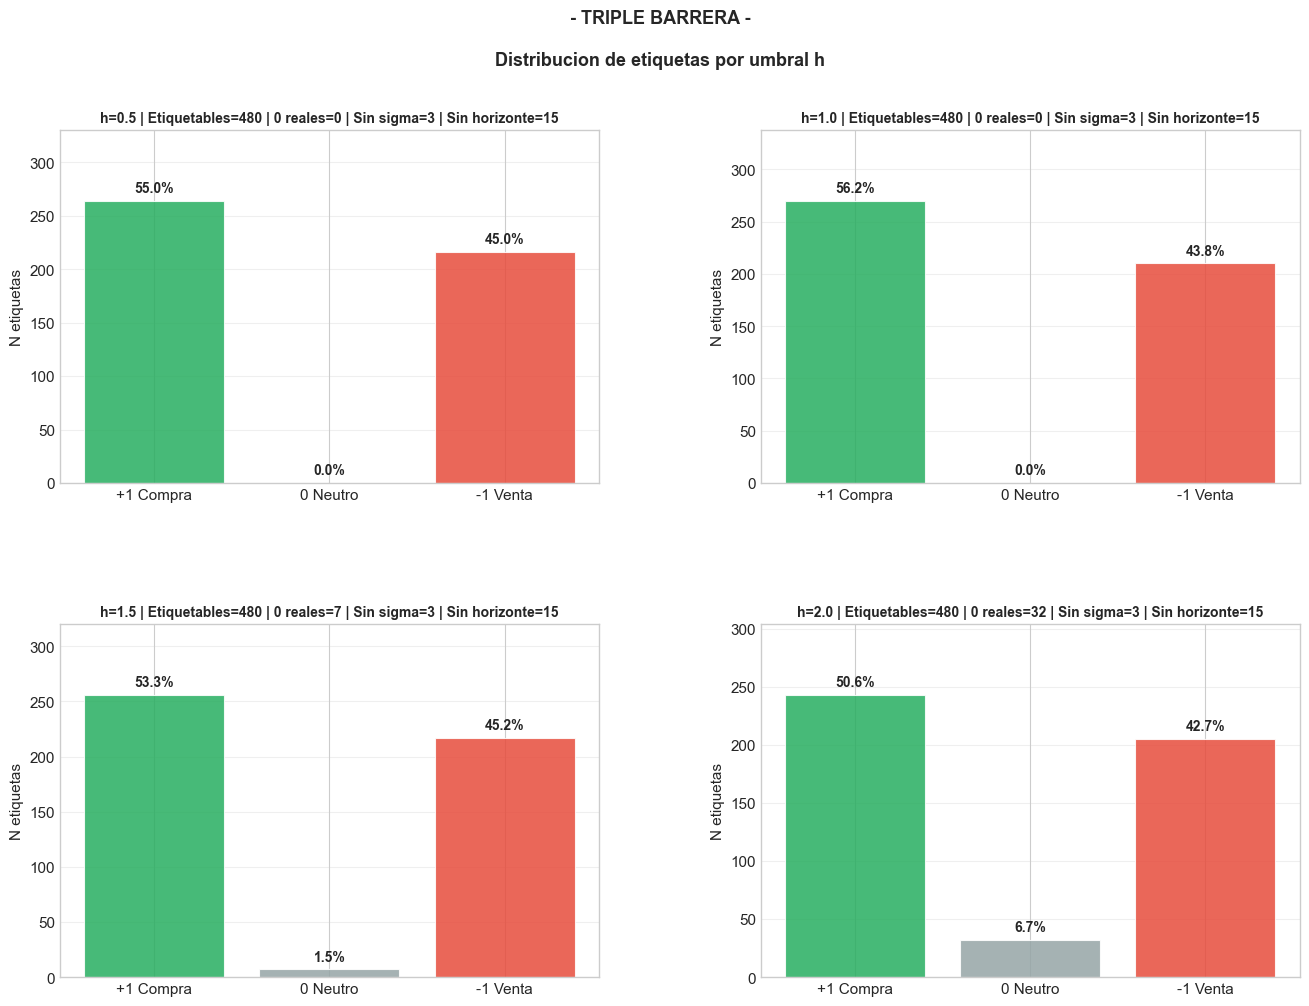

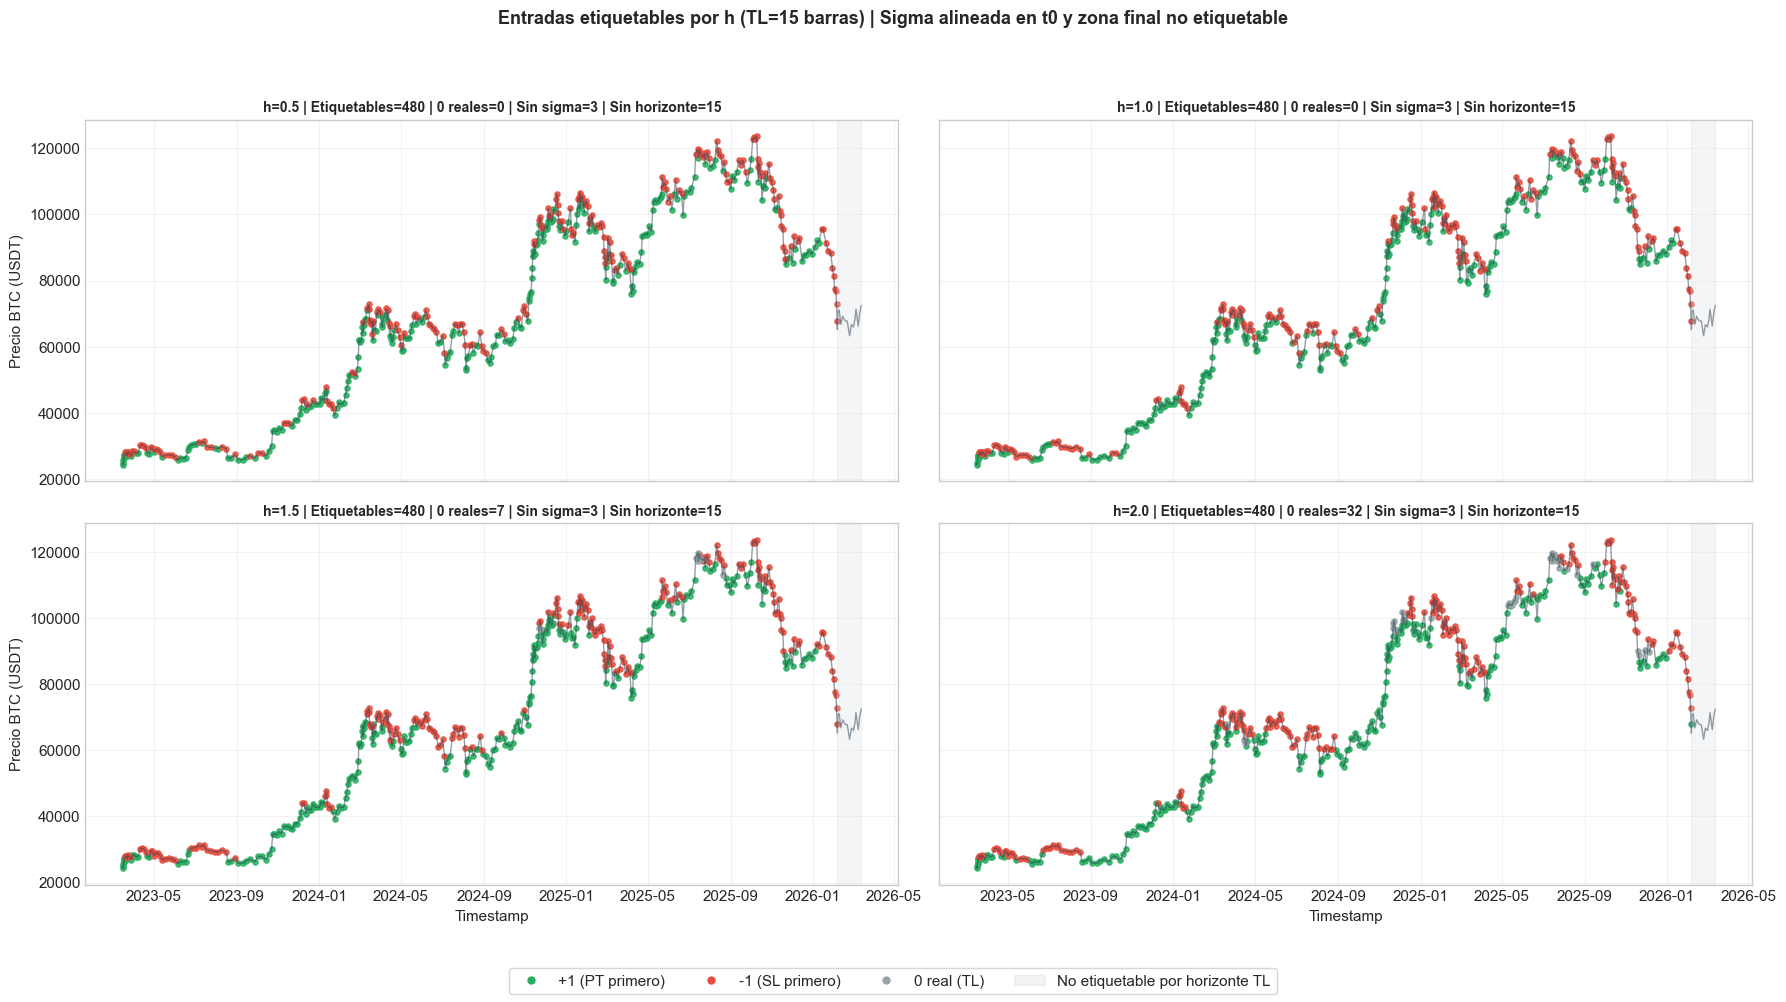

In [86]:
# VISUALIZACION
# Distribucion de etiquetas y puntos de entrada por h.

# Figura 1: distribucion de etiquetas por h.
fig = plt.figure(figsize=(16, 11))
gs = gridspec.GridSpec(2, 2, figure=fig, hspace=0.40, wspace=0.30)
fig.suptitle('- TRIPLE BARRERA -\n\nDistribucion de etiquetas por umbral h',
             fontsize=13, fontweight='bold', y=0.99)

for (row, col), h in zip([(0, 0), (0, 1), (1, 0), (1, 1)], valores_h):
    ax = fig.add_subplot(gs[row, col])
    etqs = etiquetas_h[h]
    conteo = Counter(etqs.values)

    categorias = ['+1 Compra', '0 Neutro', '-1 Venta']
    valores = [conteo.get(1, 0), conteo.get(0, 0), conteo.get(-1, 0)]
    colores = ['#27AE60', '#95A5A6', '#E74C3C']

    bars = ax.bar(categorias, valores, color=colores, alpha=0.85, edgecolor='white', lw=0.8)
    vmax = max(valores) if max(valores) > 0 else 1

    for bar, v in zip(bars, valores):
        pct = (v / len(etqs) * 100) if len(etqs) > 0 else 0
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() + vmax * 0.02,
                f'{pct:.1f}%', ha='center', va='bottom', fontsize=10, fontweight='bold')

    r = resumen_h[h]
    ax.set_title(
        f'h={h} | Etiquetables={r["etiquetables"]} | 0 reales={r["cero_reales"]} | '
        f'Sin sigma={r["no_sigma"]} | Sin horizonte={r["no_horizonte"]}',
        fontsize=10,
    )
    ax.set_ylabel('N etiquetas')
    ax.set_ylim(0, vmax * 1.25)
    ax.grid(True, alpha=0.3, axis='y')

plt.savefig('t4_triple_barrera_distribucion.png', dpi=130, bbox_inches='tight')
plt.show()

# Figura 2: todos los puntos de entrada etiquetables por h.
fig2, axes = plt.subplots(2, 2, figsize=(18, 10), sharex=True, sharey=True)
fig2.suptitle(
    f'Entradas etiquetables por h (TL={N_BARRAS_TL} barras) | '
    'Sigma alineada en t0 y zona final no etiquetable',
    fontsize=13,
    fontweight='bold',
    y=0.99,
)

for ax, h in zip(axes.flatten(), valores_h):
    etqs = etiquetas_h[h].sort_index()

    idx_pos = etqs[etqs == 1].index
    idx_neg = etqs[etqs == -1].index
    idx_zer = etqs[etqs == 0].index

    ax.plot(precios_tb.index, precios_tb.values, color='#2C3E50', lw=1.0, alpha=0.50)
    if len(idx_pos) > 0:
        ax.scatter(idx_pos, precios_tb.loc[idx_pos], s=14, c='#27AE60', alpha=0.85, label='+1')
    if len(idx_neg) > 0:
        ax.scatter(idx_neg, precios_tb.loc[idx_neg], s=14, c='#E74C3C', alpha=0.85, label='-1')
    if len(idx_zer) > 0:
        ax.scatter(idx_zer, precios_tb.loc[idx_zer], s=14, c='#95A5A6', alpha=0.90, label='0 real')

    if N_BARRAS_TL > 0 and len(precios_tb) >= N_BARRAS_TL:
        zona_ini = precios_tb.index[-N_BARRAS_TL]
        zona_fin = precios_tb.index[-1]
        ax.axvspan(zona_ini, zona_fin, color='#D7DBDD', alpha=0.25)

    r = resumen_h[h]
    ax.set_title(
        f'h={h} | Etiquetables={r["etiquetables"]} | 0 reales={r["cero_reales"]} | '
        f'Sin sigma={r["no_sigma"]} | Sin horizonte={r["no_horizonte"]}',
        fontsize=10,
    )
    ax.grid(True, alpha=0.25)

legend_handles = [
    plt.Line2D([0], [0], marker='o', color='w', markerfacecolor='#27AE60', markersize=7, label='+1 (PT primero)'),
    plt.Line2D([0], [0], marker='o', color='w', markerfacecolor='#E74C3C', markersize=7, label='-1 (SL primero)'),
    plt.Line2D([0], [0], marker='o', color='w', markerfacecolor='#95A5A6', markersize=7, label='0 real (TL)'),
    mpatches.Patch(color='#D7DBDD', alpha=0.35, label='No etiquetable por horizonte TL'),
]
fig2.legend(handles=legend_handles, loc='lower center', ncol=4, frameon=True)

for ax in axes[1, :]:
    ax.set_xlabel('Timestamp')
for ax in axes[:, 0]:
    ax.set_ylabel('Precio BTC (USDT)')

plt.tight_layout(rect=[0, 0.06, 1, 0.95])
plt.savefig('t4_triple_barrera_entradas_por_h.png', dpi=130, bbox_inches='tight')
plt.show()

> <u>Comentario</u>:
>
> - La **distribución de etiquetas por h** muestra cómo el umbral *h* modifica el balance entre las tres clases: con *h* bajo (0.5, 1.0), las barreras PT y SL están tan cerca que prácticamente todos los puntos tocan una de las dos antes del límite temporal, por lo que la clase neutra (0) es inexistente. A medida que *h* aumenta (1.5, 2.0), las barreras se alejan y el porcentaje de «0 reales» crece (hasta 6.7% en h=2.0), casos en los que el precio no alcanza ni profit taking ni stop loss dentro de TL=15 barras. Las clases +1 y -1 se mantienen relativamente equilibradas en todos los umbrales (~50-56% compra, ~43-45% venta), lo que indica que el etiquetado no introduce un sesgo direccional marcado.
>
> - El **gráfico de entradas etiquetables sobre el precio** demuestra la sensibilidad del etiquetado al parámetro *h*: al pasar de *h*=0.5 a *h*=2.0, el número de «0 reales» (puntos grises) crece de 0 a 32 en las mismas 480 entradas. Con *h* bajo, las barreras están cerca y casi todos los puntos alcanzan PT o SL antes del límite temporal; con *h* alto, las barreras se alejan y, manteniendo TL=15 fijo, muchos puntos quedan en zona de indecisión. La comparación lado a lado permite calibrar *h* según el trade-off deseado: más señales de salida clara (PT/SL) con *h* bajo, o más filtrado de ruido con *h* alto a costa de aumentar la clase neutra.

## <font color=#0099CC>**6. VALIDACIÓN CRUZADA PURGADA**</font>

El K-Fold estándar no es válido en series temporales financieras debido a la correlación serial y al solapamiento de ventanas de evento. El Purged K-Fold elimina las observaciones contaminadas del conjunto de entrenamiento y aplica un embargo temporal para evitar la fuga de información entre folds.


### <font color=#336699>**6.1. El Problema: ¿Por Qué el K-Fold Estándar no es Válido en Series Temporales?**</font>

El K-Fold tradicional divide los datos en folds de forma aleatoria, asumiendo que las observaciones son **independientes entre sí**. En datos tabulares clásicos (clasificación de imágenes, detección de spam, etc.) esta asunción es razonable, pero en series temporales financieras se viola por dos motivos:

1. **Correlación serial:** el estado del mercado en el instante `t` está directamente ligado al instante `t-1`. Si una observación de `t` cae en test y otra de `t-1` en train, el modelo de entrenamiento ha visto información casi idéntica a la que se le pide predecir.

2. **Ventanas de evento solapadas:** al usar la triple barrera (T4), cada etiqueta se genera a partir de una ventana `[t0, t0+TL]`. Etiquetas consecutivas comparten gran parte de esa ventana. Si una cae en train y otra en test, la información es esencialmente la misma.

En esta práctica: con un horizonte temporal de TL=15 barras, dos observaciones separadas por menos de 15 barras comparten la mayor parte de su ventana de evento. Un K-Fold estándar permitiría que ambas caigan en folds distintos, filtrando información del futuro al entrenamiento y sobreestimando artificialmente el rendimiento fuera de muestra.



### <font color=#336699>**6.2. Solución: Purged K-Fold con Embargo**</font>

El Purged K-Fold, propuesto por López de Prado, resuelve ambos problemas mediante dos mecanismos complementarios:

- **Purging (purgado):** antes de entrenar cada fold, se eliminan del conjunto de train todas las observaciones cuyo intervalo de evento `[t0, t_end]` solape con cualquier observación del conjunto de test. De este modo, ninguna muestra de entrenamiento comparte información temporal con las muestras de evaluación.

- **Embargo:** además del purgado, se aplica una zona de exclusión temporal entre el final del bloque de test y el inicio del siguiente bloque de train. El tamaño del embargo se liga al horizonte de la triple barrera: se usa al menos `TL/n_folds` (en nuestro caso ~3%-4% de las observaciones), en lugar de un valor fijo arbitrario. Esto garantiza que la separación temporal sea coherente con la escala de las etiquetas.

El resultado es una validación cruzada que respeta la estructura temporal de los datos y produce estimaciones de rendimiento más realistas y conservadoras que el K-Fold estándar.



#### **6.2.1. Limpieza de Features sin Leakage**

Un aspecto sutil pero crítico es cómo integrar la limpieza de covarianza (T3) con la validación purgada sin introducir fuga de información. Si se aplica el denoise de Marchenko-Pastur sobre *todo* el dataset antes de dividir en folds, los parámetros de limpieza (eigenvalores, eigenvectores) contienen información del test, contaminando la evaluación.

Para evitarlo, en esta práctica se compara una variante donde la limpieza MP se aplica **dentro de cada fold de entrenamiento**: los parámetros de denoise se estiman solo con las observaciones de train, y el test se transforma con esos mismos parámetros. De este modo, la limpieza de features mejora la calidad de los inputs sin violar la separación temporal.

> Esta integración conecta T3 con T5 de forma correcta: la limpieza de covarianza se convierte en un paso de preprocesado *dentro* del pipeline de validación, no un paso previo que contaminaría los resultados.

In [90]:
# PURGED K-FOLD CROSS-VALIDATION
# Input: features BTC (T3-B) + etiquetas_h1 y detalles_h1 (T4)

from sklearn.ensemble import RandomForestClassifier  # modelo para la demo
from sklearn.model_selection import KFold            # K-Fold estandar (baseline)
from sklearn.metrics import accuracy_score           # metrica de evaluacion


def fit_mp_feature_cleaner(X_train_df):
    """
    Ajusta un transformador MP denoised usando SOLO train.

    Flujo:
      1) estandarizar en train
      2) calcular correlacion y eigenspectrum
      3) contraer eigenvalores de ruido (Marchenko-Pastur)
      4) construir matriz lineal de transformacion para train/test
    """
    mu = X_train_df.mean()
    sd = X_train_df.std(ddof=0).replace(0, 1.0)

    Z = ((X_train_df - mu) / sd).replace([np.inf, -np.inf], np.nan).fillna(0.0)
    C = np.corrcoef(Z.values, rowvar=False)

    evals, evecs = eigh(C)
    order = evals.argsort()[::-1]
    evals = evals[order]
    evecs = evecs[:, order]

    t_obs, n_feat = Z.shape
    q_fold = t_obs / n_feat
    lambda_max_fold = (1 + 1 / np.sqrt(q_fold)) ** 2 if q_fold > 1 else np.inf

    mask_noise = evals <= lambda_max_fold
    evals_clean = evals.copy()
    if mask_noise.any():
        evals_clean[mask_noise] = evals[mask_noise].mean()

    evals_safe = np.clip(evals, 1e-12, None)
    shrink = np.sqrt(np.clip(evals_clean, 1e-12, None) / evals_safe)
    A = evecs @ np.diag(shrink) @ evecs.T

    return {
        'cols': list(X_train_df.columns),
        'mu': mu,
        'sd': sd,
        'A': A,
        'lambda_max': float(lambda_max_fold),
        'n_signal': int((~mask_noise).sum()),
        'n_noise': int(mask_noise.sum()),
    }


def transform_with_mp_cleaner(X_df, cleaner):
    """Transforma cualquier bloque (train/test) con parametros aprendidos en train."""
    X = X_df.reindex(columns=cleaner['cols']).copy()
    Z = ((X - cleaner['mu']) / cleaner['sd']).replace([np.inf, -np.inf], np.nan).fillna(0.0)
    Z_clean = Z.values @ cleaner['A']
    return pd.DataFrame(Z_clean, index=X.index, columns=cleaner['cols'])


def purged_kfold_eventos(n_obs, k, event_end_pos, embargo_bars):
    """
    Purged K-Fold con purging por intervalos [inicio, fin] de evento.

    Regla de purging:
      se excluye del train todo evento j cuyo intervalo [j, end_j]
      solape con el bloque temporal de eventos de test.
    """
    indices = np.arange(n_obs)
    fold_size = n_obs // k
    splits = []

    for i in range(k):
        test_start = i * fold_size
        test_end_exclusive = (i + 1) * fold_size if i < k - 1 else n_obs
        test_idx = indices[test_start:test_end_exclusive]
        if len(test_idx) == 0:
            continue

        # Ventana temporal efectiva cubierta por los eventos de test.
        overlap_start = int(test_idx[0])
        overlap_end = int(np.max(event_end_pos[test_idx]))

        # Purging por solape de intervalos [j, end_j] con [overlap_start, overlap_end].
        overlap_mask = (indices <= overlap_end) & (event_end_pos >= overlap_start)
        purge_idx = indices[overlap_mask]

        # Embargo posterior al fin de los eventos de test.
        embargo_start = min(n_obs, overlap_end + 1)
        embargo_end = min(n_obs, embargo_start + embargo_bars)
        embargo_idx = indices[embargo_start:embargo_end]

        excluidos = set(test_idx) | set(purge_idx) | set(embargo_idx)
        train_idx = np.array([j for j in indices if j not in excluidos], dtype=int)

        splits.append((train_idx, test_idx))

    return splits


# Dataset de modelado: T3-B features + etiquetas de T4 (h=1.0)
if 'btc_feat_df' not in globals():
    raise ValueError('No existe btc_feat_df. Ejecuta primero la celda de T3-B.')
if 'detalles_h1' not in globals():
    raise ValueError('No existe detalles_h1. Ejecuta primero la celda de T4.')

X_df = btc_feat_df.copy()
y_s = etiquetas_h1.copy()

idx_c = X_df.index.intersection(y_s.index)
idx_c = idx_c.sort_values()
X_df = X_df.loc[idx_c].copy()
y_s = y_s.loc[idx_c].astype(int)

# Convertimos t_end de cada etiqueta a posicion entera dentro de idx_c.
det_map = detalles_h1.set_index('t0').reindex(idx_c)
end_ts = det_map['t_end'].values
idx_vals = idx_c.values
event_end_pos = np.searchsorted(idx_vals, end_ts, side='right') - 1
event_end_pos = np.clip(event_end_pos, 0, len(idx_c) - 1)

n = len(idx_c)
if n < 120:
    raise ValueError(f'Muy pocas observaciones para T5 tras alinear features/etiquetas: n={n}')

pct_embargo = max(0.01, N_BARRAS_TL / n)
embargo_bars = max(N_BARRAS_TL, int(np.ceil(pct_embargo * n)))

X_np = X_df.values
y_np = y_s.values

print(f'Dataset:')
print(f'  > Tamaño: n={n}')
print(f'  > Features={X_df.shape[1]}')
print(f'  > Embargo dinamico: pct={pct_embargo:.4f} ({pct_embargo*100:.2f}%) | barras={embargo_bars}')
print(f'  > Horizonte de etiqueta TL={N_BARRAS_TL} barras')


# Comparacion de validaciones
#   1) K-Fold estandar (raw)
#   2) Purged K-Fold (raw)
#   3) Purged K-Fold + T3 denoised fold-wise
modelo = RandomForestClassifier(n_estimators=120, max_depth=4, random_state=42)
K_valores = [3, 5, 10]
resultados = {}
splits_purged_cache = {}

print(f'\nTabla comparativa:')
print(f"\n{'K':>4} | {'KFold raw':>21} | {'Purged raw':>21} | {'Purged + T3 denoise':>22}")
print('  ' + '-' * 84)

for K in K_valores:
    scores_std = []
    scores_purged = []
    scores_purged_denoised = []

    # Baseline: K-Fold estandar sin purging.
    for tr, te in KFold(n_splits=K, shuffle=False).split(X_np):
        if len(tr) < 50 or len(te) < 20:
            continue
        if len(np.unique(y_np[tr])) < 2:
            continue

        modelo.fit(X_np[tr], y_np[tr])
        pred = modelo.predict(X_np[te])
        scores_std.append(accuracy_score(y_np[te], pred))

    # Purged K-Fold por intervalos de evento + embargo coherente.
    splits_p = purged_kfold_eventos(n, k=K, event_end_pos=event_end_pos, embargo_bars=embargo_bars)
    splits_purged_cache[K] = splits_p

    for tr, te in splits_p:
        if len(tr) < 50 or len(te) < 20:
            continue
        if len(np.unique(y_np[tr])) < 2:
            continue

        # 2) Purged raw.
        modelo.fit(X_np[tr], y_np[tr])
        pred_p = modelo.predict(X_np[te])
        scores_purged.append(accuracy_score(y_np[te], pred_p))

        # 3) Purged + T3 denoise ajustado SOLO en train.
        cleaner = fit_mp_feature_cleaner(X_df.iloc[tr])
        Xtr_clean = transform_with_mp_cleaner(X_df.iloc[tr], cleaner).values
        Xte_clean = transform_with_mp_cleaner(X_df.iloc[te], cleaner).values

        modelo.fit(Xtr_clean, y_np[tr])
        pred_pd = modelo.predict(Xte_clean)
        scores_purged_denoised.append(accuracy_score(y_np[te], pred_pd))

    resultados[K] = {
        'std_raw': scores_std,
        'purged_raw': scores_purged,
        'purged_denoised': scores_purged_denoised,
    }

    def fmt(scores):
        if len(scores) == 0:
            return 'N/A'
        return f"{np.mean(scores)*100:.2f}% +- {np.std(scores)*100:.2f}%"

    print(
        f"  {K:>3} | {fmt(scores_std):>21} | {fmt(scores_purged):>21} | "
        f"{fmt(scores_purged_denoised):>22}"
    )

Dataset:
  > Tamaño: n=384
  > Features=12
  > Embargo dinamico: pct=0.0391 (3.91%) | barras=15
  > Horizonte de etiqueta TL=15 barras

Tabla comparativa:

   K |             KFold raw |            Purged raw |    Purged + T3 denoise
  ------------------------------------------------------------------------------------
    3 |       60.42% +- 4.79% |       58.85% +- 4.83% |        61.20% +- 4.79%
    5 |       59.11% +- 6.72% |       59.11% +- 7.84% |        61.16% +- 8.18%
   10 |      60.65% +- 10.04% |      57.34% +- 12.84% |        58.56% +- 9.44%


#### **6.2.2. Visualización de Resultados**

Se representan gráficamente los folds de validación purgada, comparando el rendimiento con y sin limpieza de features (MP).

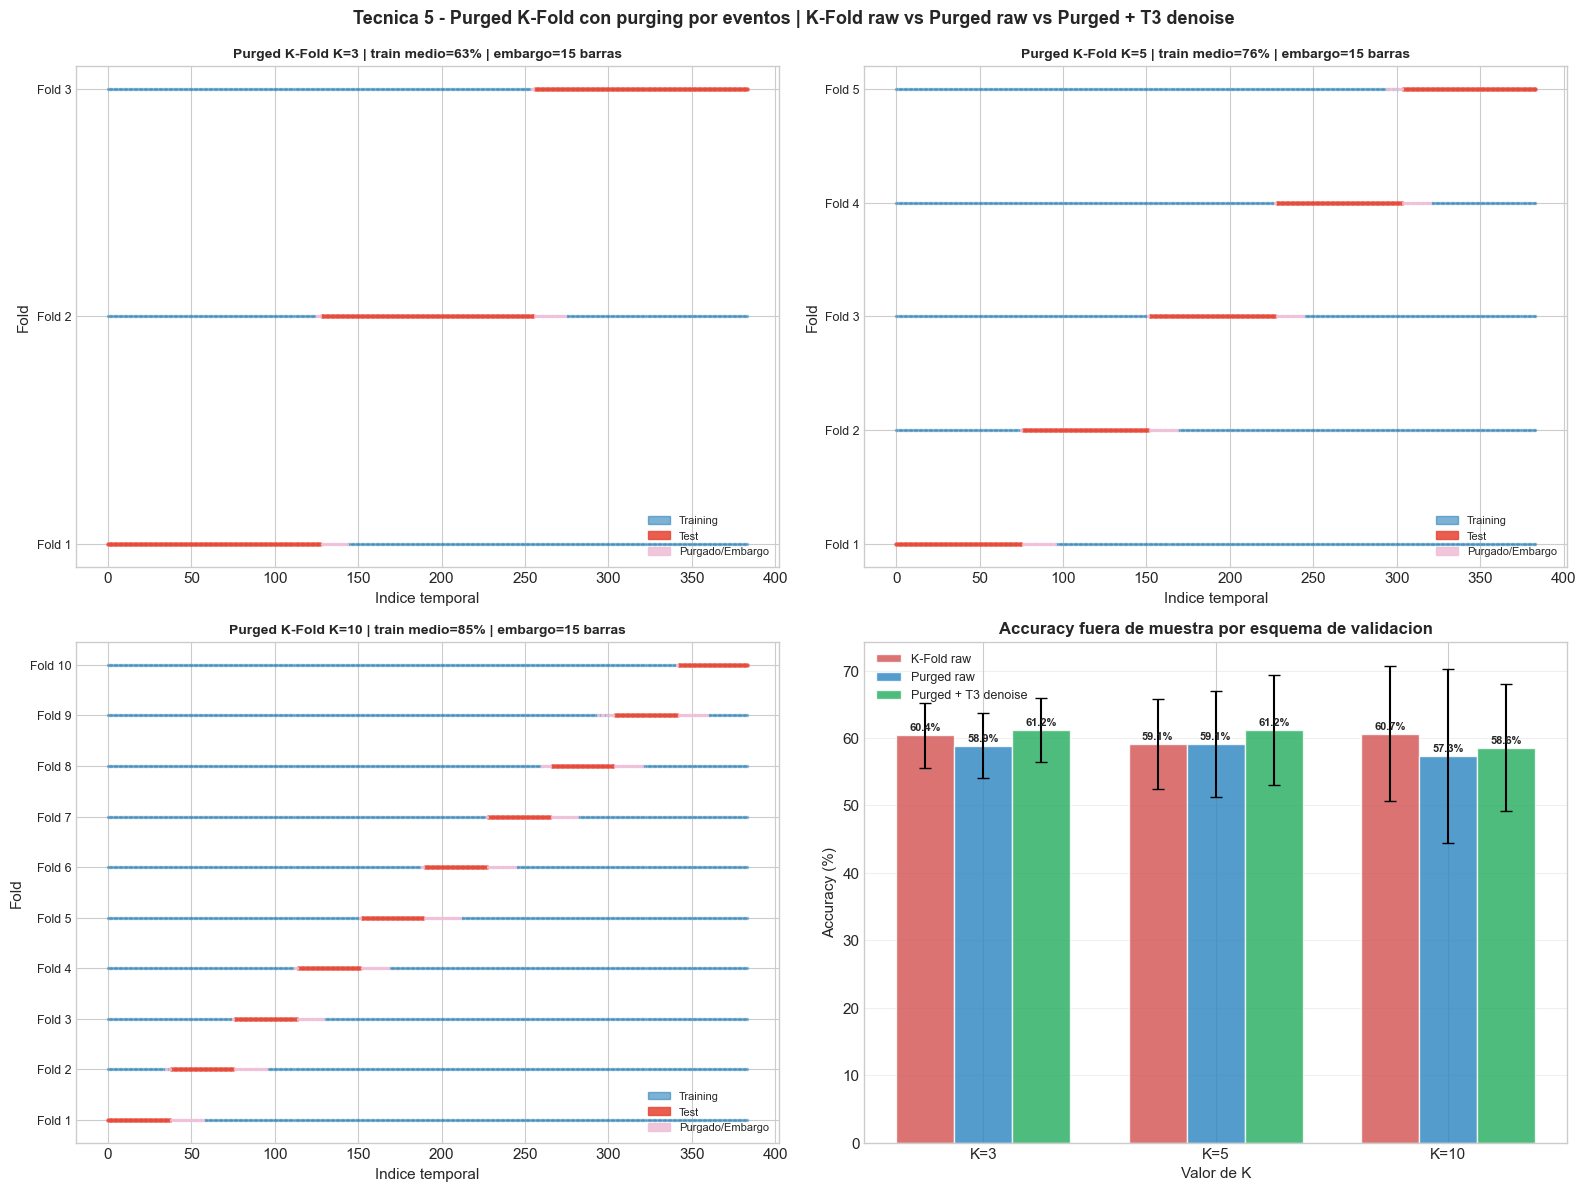


Interpretacion final T5:
  - K-Fold raw = optimista por fuga temporal.
  - Purged raw = evaluacion mas honesta.
  - Purged + T3 denoise = impacto de limpiar features dentro de cada fold (sin leakage).


In [ ]:
# VISUALIZACION

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle(
    'Tecnica 5 - Purged K-Fold con purging por eventos | '
    'K-Fold raw vs Purged raw vs Purged + T3 denoise',
    fontsize=13,
    fontweight='bold',
    y=0.99,
)

K_show = [3, 5, 10]
for (row, col), K_v in zip([(0, 0), (0, 1), (1, 0)], K_show):
    ax = axes[row, col]
    splits_v = splits_purged_cache[K_v]

    for fi, (tr, te) in enumerate(splits_v):
        todos = set(range(n))
        usados = set(tr) | set(te)
        excl = sorted(todos - usados)

        step_tr = max(1, len(tr) // 220)
        step_ex = max(1, len(excl) // 140) if len(excl) > 0 else 1

        ax.scatter(tr[::step_tr], [fi] * len(tr[::step_tr]), c=COLORS['train'], s=6, alpha=0.50, linewidths=0)
        ax.scatter(te, [fi] * len(te), c=COLORS['test'], s=10, alpha=0.90, linewidths=0)
        if excl:
            ax.scatter(excl[::step_ex], [fi] * len(excl[::step_ex]), c=COLORS['purge'], s=6, alpha=0.90, linewidths=0)

    pct_tr = np.mean([len(t) for t, _ in splits_v]) / n * 100
    ax.set_title(f'Purged K-Fold K={K_v} | train medio={pct_tr:.0f}% | embargo={embargo_bars} barras', fontsize=10)
    ax.set_xlabel('Indice temporal')
    ax.set_ylabel('Fold')
    ax.set_yticks(range(len(splits_v)))
    ax.set_yticklabels([f'Fold {i + 1}' for i in range(len(splits_v))], fontsize=9)

    ley = [
        mpatches.Patch(color=COLORS['train'], alpha=0.6, label='Training'),
        mpatches.Patch(color=COLORS['test'], alpha=0.9, label='Test'),
        mpatches.Patch(color=COLORS['purge'], alpha=0.9, label='Purgado/Embargo'),
    ]
    ax.legend(handles=ley, fontsize=8, loc='lower right')

# Panel de metricas comparadas.
ax_c = axes[1, 1]
K_l = sorted(resultados.keys())

m_std = [np.mean(resultados[K]['std_raw']) if resultados[K]['std_raw'] else np.nan for K in K_l]
m_pr = [np.mean(resultados[K]['purged_raw']) if resultados[K]['purged_raw'] else np.nan for K in K_l]
m_pd = [np.mean(resultados[K]['purged_denoised']) if resultados[K]['purged_denoised'] else np.nan for K in K_l]

e_std = [np.std(resultados[K]['std_raw']) if resultados[K]['std_raw'] else 0.0 for K in K_l]
e_pr = [np.std(resultados[K]['purged_raw']) if resultados[K]['purged_raw'] else 0.0 for K in K_l]
e_pd = [np.std(resultados[K]['purged_denoised']) if resultados[K]['purged_denoised'] else 0.0 for K in K_l]

x = np.arange(len(K_l))
w = 0.25

b1 = ax_c.bar(x - w, [v * 100 for v in m_std], w, yerr=[v * 100 for v in e_std], capsize=4,
              color='#D35454', alpha=0.82, edgecolor='white', label='K-Fold raw')
b2 = ax_c.bar(x, [v * 100 for v in m_pr], w, yerr=[v * 100 for v in e_pr], capsize=4,
              color='#2E86C1', alpha=0.82, edgecolor='white', label='Purged raw')
b3 = ax_c.bar(x + w, [v * 100 for v in m_pd], w, yerr=[v * 100 for v in e_pd], capsize=4,
              color='#27AE60', alpha=0.82, edgecolor='white', label='Purged + T3 denoise')

for bars in [b1, b2, b3]:
    for bar in bars:
        h = bar.get_height()
        if not np.isnan(h):
            ax_c.text(bar.get_x() + bar.get_width() / 2, h + 0.35,
                      f'{h:.1f}%', ha='center', va='bottom', fontsize=8, fontweight='bold')

ax_c.set_title('Accuracy fuera de muestra por esquema de validacion')
ax_c.set_xlabel('Valor de K')
ax_c.set_ylabel('Accuracy (%)')
ax_c.set_xticks(x)
ax_c.set_xticklabels([f'K={k}' for k in K_l])
ax_c.legend(fontsize=9)
ax_c.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('t5_purged_kfold.png', dpi=130, bbox_inches='tight')
plt.show()

> <u>Comentario</u>:
>
> - Los **tres paneles superiores** muestran cómo se divide el dataset (n=384) en cada Purged K-Fold: azul (train), rojo (test) y rosa (purgado/embargo). El embargo de 15 barras aparece como franjas rosas entre bloques de test y train, impidiendo que observaciones temporalmente cercanas contaminen la evaluación. A medida que *K* aumenta (3 → 5 → 10), el tamaño de cada bloque de test disminuye y el porcentaje de datos disponibles para entrenar crece (63% → 76% → 85%), pero el coste es que cada fold de test tiene menos muestras y la varianza de las estimaciones aumenta.
>
> - El **panel inferior** (barras de accuracy) resume el trade-off entre los tres esquemas: el K-Fold raw tiende a sobrestimar (60.4%–60.7%) por fuga temporal; el Purged raw ofrece estimaciones más honestas y generalmente más bajas (57.3%–59.1%); el Purged + T3 denoise mejora respecto a Purged raw en K=3 y K=5 (~61.2%), indicando que la limpieza de covarianza reduce ruido en los features cuando se aplica correctamente dentro de cada fold. En K=10, las barras de error crecen de forma notable en los tres métodos (especialmente en Purged raw, ±12.8%): más folds implican bloques de test más pequeños y estimaciones menos estables. La visualización integra el mecanismo de purgado (diagramas temporales) con el resultado numérico (accuracy), mostrando que la validación purgada sacrifica parte del rendimiento aparente a cambio de estimaciones fuera de muestra más fiables.

## <font color=#0099CC>**7. CONCLUSIÓN**</font>

Este notebook ha presentado un **pipeline de preprocesado** para Machine Learning aplicado a datos financieros, siguiendo el marco de López de Prado (2018). Las cinco técnicas desarrolladas abordan de forma encadenada los problemas que hacen fracasar el ML estándar en finanzas.

### <font color=#336699>**7.1. Resumen del pipeline**</font>

| Técnica | Problema que resuelve | Resultado en esta práctica |
|---------|----------------------|----------------------------|
| **Barras alternativas** | Heterocedasticidad de las time bars | Dollar bars reducen la curtosis de ~99 a ~0.5, aproximando una distribución mesocúrtica |
| **Diferenciación fraccional** | Estacionariedad vs. memoria | d=0.4 logra estacionariedad (ADF p<0.05) preservando autocorrelación de largo plazo |
| **Limpieza de covarianza (MP)** | Ruido estadístico en matrices | Denoise y detone separan señal de ruido; en features (N=12) el denoise tiene efecto visible |
| **Triple barrera** | Etiquetas irreales (horizonte fijo) | Etiquetas que incorporan PT, SL y TL con volatilidad adaptativa; balance ~50/50 entre +1 y -1 |
| **Purged K-Fold** | Data leakage en validación | Estimaciones más conservadoras; integración correcta de T3 (denoise dentro de cada fold) |

### <font color=#336699>**7.2. Conectando las piezas**</font>

El flujo resultante no es una secuencia arbitraria: cada paso alimenta al siguiente. Las **dollar bars** (T1) sustituyen las velas temporales como base de series y features. Sobre ellas se aplica la **diferenciación fraccional** (T2) para obtener series estacionarias pero con memoria. La **limpieza de covarianza** (T3) se usa en dos contextos — multi-activo (gestión de riesgo) y features de un solo activo (inputs de modelos) — con efectos distintos según el régimen estadístico. Las **etiquetas de triple barrera** (T4) generan ventanas de evento solapadas que el **Purged K-Fold** (T5) debe purgar en validación para evitar fuga temporal. La limpieza T3 se integra dentro de cada fold de T5, no antes, para no contaminar la evaluación.

### <font color=#336699>**7.3. Implicación práctica**</font>

El rendimiento reportado por un modelo entrenado con validación estándar (K-Fold sin purgar) suele ser **optimista**. Los resultados de este notebook ilustran esa brecha: el K-Fold raw sitúa la accuracy en ~60%, mientras que el Purged raw la reduce a ~57–59%. La diferencia no indica que el modelo sea peor, sino que la primera estimación estaba inflada por información futura que en producción nunca existiría. Aplicar estas técnicas de preprocesado y validación reduce el riesgo de falsos positivos y produce estimaciones de rendimiento fuera de muestra más fiables, a costa de asumir que el "número bonito" del backtest será más bajo — y más honesto — que el que ofrecería una validación ingenua.